# Verificación del Directorio

# Importanción de paquetes requeridos

In [1]:
import statsmodels.api as sm
import scipy.stats as stats
import pylab
import statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#sns.set()
#importacion de paquetes para el calculo de V de Cramer, Chi**2
from scipy.stats import chi2_contingency, chi2,shapiro,normaltest,anderson
import seaborn as sns
#import statsmodels.api as sm
from statsmodels.formula.api import ols
#from sklearn.impute import SimpleImputer

#from sklearn.model_selection import train_test_split
# from feature-engine
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# el modulo a instarlar en este caso es pip install sklearn-pandas con "-"
#from sklearn_pandas import DataFrameMapper
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
#warnings.filterwarnings('ignore')
#import xgboost as xgb
from sklearn.model_selection import cross_val_score
#from xgboost import plot_tree
from sklearn.calibration import calibration_curve
%matplotlib inline
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms

In [2]:
#Load ENAHO csv file
from google.colab import files
load=files.upload()

Saving BD_Life_expectancy_Clasificacion.xlsx to BD_Life_expectancy_Clasificacion.xlsx


# Lectura de la muestra inicial

In [3]:
# muestra todas las columns de la bd
pd.set_option('display.max_columns', None)

#lectura muestra inical de deserción del 1C
data = pd.read_excel('BD_Life_expectancy_Clasificacion.xlsx')

#muestra los primeros dos registros de la tabla leida
data.head(20)

,Country,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,Developing,58.193750,269.062500,78.250000,0.014375,34.960110,64.562500,2362.250000,15.518750,107.562500,48.375000,8.252500,52.312500,340.015425,9.972260e+06,16.581250,15.581250,0.415375,8.212500
1,Albania,Developing,75.156250,45.062500,0.687500,4.848750,193.259091,98.000000,53.375000,49.068750,0.937500,98.125000,5.945625,98.062500,2119.726679,6.969116e+05,1.618750,1.700000,0.709875,12.137500
2,Algeria,Developing,74.209091,102.818182,20.272727,0.447273,300.271939,76.454545,647.000000,48.872727,23.363636,93.181818,4.945455,93.363636,3261.289374,2.412474e+07,6.000000,5.890909,0.707182,13.163636
3,Angola,Developing,50.675000,362.750000,76.625000,7.620000,174.405789,71.000000,3925.625000,18.450000,118.750000,70.875000,3.653750,64.000000,2935.762962,1.010785e+07,9.037500,8.925000,0.492875,9.475000
4,Argentina,Developing,75.238462,100.384615,10.000000,8.004615,838.198889,80.307692,2.000000,54.484615,11.230769,94.461538,6.546154,93.692308,6932.546882,2.084745e+07,1.061538,0.930769,0.795769,16.630769
5,Armenia,Developing,73.306667,117.333333,1.000000,3.702667,139.741247,87.133333,290.333333,44.026667,1.000000,88.666667,4.861333,86.933333,2108.675087,1.063396e+06,2.033333,2.106667,0.695533,11.726667
6,Australia,Developed,81.907143,62.428571,1.000000,10.154286,6069.174015,93.428571,105.785714,54.928571,1.357143,91.857143,8.839286,92.000000,35391.195154,3.541690e+06,0.671429,0.621429,0.918286,19.985714
7,Austria,Developed,81.480000,65.800000,0.000000,12.236000,5257.001801,80.266667,61.800000,47.666667,0.000000,85.533333,4.715333,86.333333,33171.578263,6.330994e+06,1.720000,1.926667,0.860400,15.353333
8,Azerbaijan,Developing,71.146154,119.846154,5.769231,1.055385,158.398549,56.384615,675.923077,43.407692,6.769231,74.076923,5.849231,82.153846,4004.784071,1.906076e+06,2.869231,2.923077,0.708231,11.415385
9,Bangladesh,Developing,69.966667,135.666667,142.416667,0.010000,42.470576,76.000000,5096.916667,14.441667,184.833333,87.666667,2.952500,94.750000,573.581681,4.598834e+07,16.200000,12.258333,0.525667,8.866667


In [4]:
data.shape

(133, 20)

In [5]:
# Eliminar los espacios de los nombres de las columnas
data.columns = data.columns.str.replace(' ', '')

In [6]:
data.columns = data.columns.str.replace('-', '_')

In [7]:
#Descripcion de la base de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       133 non-null    object 
 1   Status                        133 non-null    object 
 2   Lifeexpectancy                133 non-null    float64
 3   AdultMortality                133 non-null    float64
 4   infantdeaths                  133 non-null    float64
 5   Alcohol                       133 non-null    float64
 6   percentageexpenditure         133 non-null    float64
 7   HepatitisB                    133 non-null    float64
 8   Measles                       133 non-null    float64
 9   BMI                           133 non-null    float64
 10  under_fivedeaths              133 non-null    float64
 11  Polio                         133 non-null    float64
 12  Totalexpenditure              133 non-null    float64
 13  Dipht

## Variables con valores únicos

In [8]:
###Aqui está el problema
#Procedimiento para verificar variables con un solo valor o categoría
variables_categoricas = data.select_dtypes(['object']).columns
categorias_unicas = data[variables_categoricas]\
.apply(lambda x: len(x.dropna().unique()))
categorias_unicas

,0
Country,133
Status,2


## Creación de función para describir las variables en la muestra

In [9]:
#creación de función para explorar y describir los datos
def exploracion_de_datos(df):
    """funcion que toma por argumento el DataFrame y genera un objeto de tipo DataFrame con detalles de los datos agregando una columna llamada descripcion
    donde se detallaran cada variable """

    columns = ['Variable','Tipo_variable','Valores_nulos','%_nulos' ,'Ejemplo', 'Definicion' ]
    definicion = ['' for i in range(len(df))]

    # guarda en "variables" la lista de las variables de la base de datos
    variables = df.columns.to_list()

    # Itera sobre cada tipo de variable y guarda los tipos de variables en una lista "variable_type"
    variable_type = [ 'Cualitativa' if col_type == 'object' else 'Numerica' if col_type == 'float64' else 'Hora-Fecha' if col_type == 'datetime64[ns]' else 'Numerica' if col_type == 'int64' else 'unknow'for col_type in df.dtypes ]

    # guarda en "null_count" el conteo de nulos para todas las variables
    null_count = df.isnull().sum().to_list()

    # calcula el porcentaje de nulos de cada variable
    porcentaje_de_nulos = round(df.isnull().sum()*100 /len(df),0)
    porcentaje_de_nulos.astype('int32')

    # obtiene un ejemplo no nulo de cada variable para colocarlo en la tabla final
    ejemplar_no_nulo = df[:100000].dropna(axis=0).iloc[0].to_list()

    # zip todas las listas en "ejemplar" y la convierte en un DataFrame
    ejemplar = zip(variables,variable_type,null_count,porcentaje_de_nulos, ejemplar_no_nulo, definicion)

    # coloca las listas zipeadas y los nombres de las columnas en un DataFrame
    general_data_frame = pd.DataFrame(ejemplar, columns = columns)

    #Exporta to Excel y lo guarda en el directorio que este activo
    #general_data_frame.to_excel('Descripcion_de_datos.xlsx')

    # return
    return general_data_frame

#genera la tabla de descripcion de datos
exploracion_de_datos(data)

,Variable,Tipo_variable,Valores_nulos,%_nulos,Ejemplo,Definicion
0,Country,Cualitativa,0,0.0,Afghanistan,
1,Status,Cualitativa,0,0.0,Developing,
2,Lifeexpectancy,Numerica,0,0.0,58.19375,
3,AdultMortality,Numerica,0,0.0,269.0625,
4,infantdeaths,Numerica,0,0.0,78.25,
5,Alcohol,Numerica,0,0.0,0.014375,
6,percentageexpenditure,Numerica,0,0.0,34.96011,
7,HepatitisB,Numerica,0,0.0,64.5625,
8,Measles,Numerica,0,0.0,2362.25,
9,BMI,Numerica,0,0.0,15.51875,


## Análisis de la variable "etiqueta" (varable objetivo: Status)

In [10]:
#aqui está el problema
#genera conteo de la variable "etiqueta"
data['Status'].value_counts()

,count
Status,
Developing,114
Developed,19


In [11]:
#genera las proporciones de las categorias de la variable "etiqueta"
data['Status'].value_counts(normalize=True)

,proportion
Status,
Developing,0.857143
Developed,0.142857


# Gráfico de barras de "etiqueta"

In [12]:
!pip install plotly

In [13]:
import plotly.graph_objects as go
temp = dict(layout=go.Layout(font=dict(family="Franklin Gothic", size=12),height=500, width=1000))

target = data['Status'].value_counts(normalize=True)
target.rename(index={1:'Developed',0:'Developing'},inplace=True)
pal, color = ['#016CC9','#DEB078'], ['#8DBAE2','#EDD3B3']
fig = go.Figure()
fig.add_trace(go.Pie(labels=target.index, values=target*100, hole=.45,
                    showlegend=True,sort=False,
                    marker=dict(colors=color,line=dict(color=pal,width=2.5)),
                    hovertemplate = "%{label} Accounts: %{value:.2f}%<extra></extra>"))

fig.update_layout(template=temp, title='Distribución de la variable "Status"',
                  legend=dict(traceorder='reversed',y=1.05,x=0),
                  uniformtext_minsize=15, uniformtext_mode='hide',width=700)
fig.show()

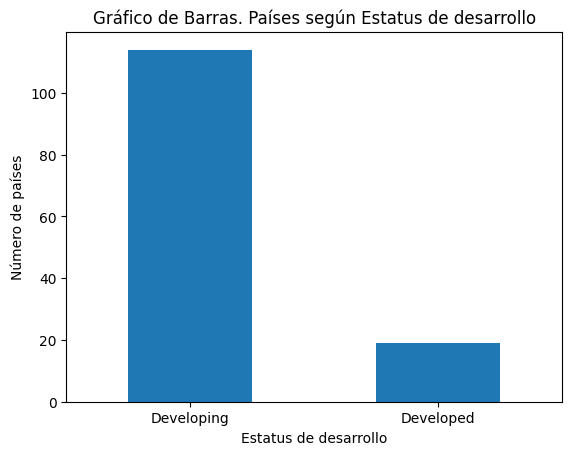

In [14]:
#grafico de barras (frecuencias) de la variable "etiqueta"

#genera el grafico de barras de valores absolutos
data['Status'].value_counts(normalize = False).plot.bar()

#título
plt.title("Gráfico de Barras. Países según Estatus de desarrollo")

#título de x
plt.xlabel("Estatus de desarrollo")

#título de y
plt.ylabel("Número de países")

#rota la inclinación de las categorias en el eje x
plt.xticks(rotation=360)

#muestra el gráfico
plt.show()

## Análisis de valores perdidos (Missing Values)

In [15]:
#aqui está el problema con population
#genera un listado de variables donde "True" significa que la variable tiene menos de 20% de valores perdidos
ind_keep = data.isna().sum()/data.shape[0] < 0.20

#se imprime el listado de variables
print(ind_keep)

Country                         True
Status                          True
Lifeexpectancy                  True
AdultMortality                  True
infantdeaths                    True
Alcohol                         True
percentageexpenditure           True
HepatitisB                      True
Measles                         True
BMI                             True
under_fivedeaths                True
Polio                           True
Totalexpenditure                True
Diphtheria                      True
GDP                             True
Population                      True
thinness1_19years               True
thinness5_9years                True
Incomecompositionofresources    True
Schooling                       True
dtype: bool


In [16]:
#crea lista de variables con valores perdidos
vars_con_na = [var for var in data.columns if data[var].isnull().sum() > 0]

# determina el porcentaje de valores perdidos (en decimales)
# muestra los resultados de forma ordenada
data[vars_con_na].isnull().mean().sort_values(ascending=False)

,0


## Separación de las variables "numéricas" y "categóricas"

In [17]:
#crea una lista de categóricas
var_cat = [var for var in data.columns if data[var].dtype == 'O']

#imprime la lista de categóricas
print(var_cat)

['Country', 'Status']


In [20]:
#Aqui está el problema year
#crea una lista de numéricas
var_num = [var for var in data.columns if var not in var_cat ]

#imprime las numéricas
print(var_num)

['Lifeexpectancy', 'AdultMortality', 'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB', 'Measles', 'BMI', 'under_fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria', 'GDP', 'Population', 'thinness1_19years', 'thinness5_9years', 'Incomecompositionofresources', 'Schooling']


## Análisis exploratorio de las variables numéricas

In [21]:
#imprime la cantidad numéricas en la muestra
print('Número de variables numéricas: ', len(var_num))

# visualiza las numéricas
data[var_num].head()

Número de variables numéricas:  18


,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under_fivedeaths,Polio,Totalexpenditure,Diphtheria,GDP,Population,thinness1_19years,thinness5_9years,Incomecompositionofresources,Schooling
0,58.193750,269.062500,78.250000,0.014375,34.960110,64.562500,2362.250,15.518750,107.562500,48.375000,8.252500,52.312500,340.015425,9.972260e+06,16.581250,15.581250,0.415375,8.212500
1,75.156250,45.062500,0.687500,4.848750,193.259091,98.000000,53.375,49.068750,0.937500,98.125000,5.945625,98.062500,2119.726679,6.969116e+05,1.618750,1.700000,0.709875,12.137500
2,74.209091,102.818182,20.272727,0.447273,300.271939,76.454545,647.000,48.872727,23.363636,93.181818,4.945455,93.363636,3261.289374,2.412474e+07,6.000000,5.890909,0.707182,13.163636
3,50.675000,362.750000,76.625000,7.620000,174.405789,71.000000,3925.625,18.450000,118.750000,70.875000,3.653750,64.000000,2935.762962,1.010785e+07,9.037500,8.925000,0.492875,9.475000
4,75.238462,100.384615,10.000000,8.004615,838.198889,80.307692,2.000,54.484615,11.230769,94.461538,6.546154,93.692308,6932.546882,2.084745e+07,1.061538,0.930769,0.795769,16.630769


## Estadisticas descriptivas de las numéricas

In [22]:
#establece el formato de los numeros a 3 decimales
pd.set_option('float_format', '{:.1f}'.format)

#genera tabla resumen de las variables numéricas
data[var_num].describe()

,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under_fivedeaths,Polio,Totalexpenditure,Diphtheria,GDP,Population,thinness1_19years,thinness5_9years,Incomecompositionofresources,Schooling
count,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0,133.0
mean,68.6,172.8,34.6,4.3,683.9,76.9,2140.9,36.9,47.6,81.8,5.9,82.2,5536.1,14679700.1,5.1,5.1,0.6,11.9
std,8.9,100.9,126.0,3.7,1367.3,17.7,7374.9,15.7,170.4,15.6,1.8,16.2,9075.5,53467185.4,4.3,4.4,0.2,2.9
min,48.4,19.9,0.0,0.0,5.0,2.0,0.0,14.4,0.0,24.0,1.1,2.0,82.2,279.0,0.1,0.1,0.2,4.9
25%,62.7,110.3,0.7,1.1,56.6,65.9,9.2,19.3,1.0,73.4,4.7,72.5,727.2,1063395.9,1.8,1.9,0.5,10.1
50%,71.1,151.3,3.3,3.6,211.1,79.2,168.4,41.4,4.0,85.8,6.0,87.2,2119.7,3674745.7,3.8,3.8,0.6,12.1
75%,74.2,230.1,23.0,7.3,551.1,91.5,1355.8,49.8,33.6,95.2,7.1,95.3,5036.1,12049555.9,7.5,7.5,0.7,13.8
max,83.4,547.2,1268.8,13.5,8722.7,98.9,67424.4,68.9,1681.8,98.6,11.8,98.9,56727.5,594387175.5,27.0,27.8,0.9,20.0


## Histogramas de numéricas

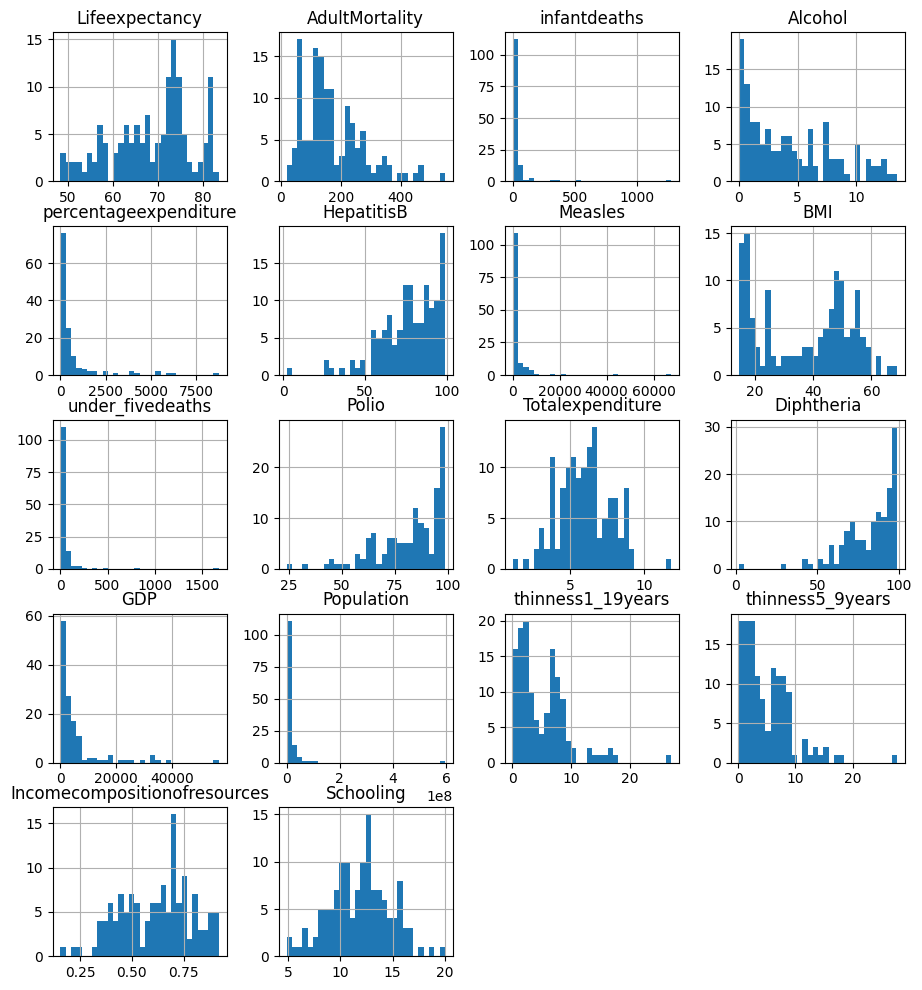

In [23]:
# genera Histogramas
data[var_num].hist(bins=30, figsize=(11,12))
plt.show()

## Análisis de normalidad

Lifeexpectancy


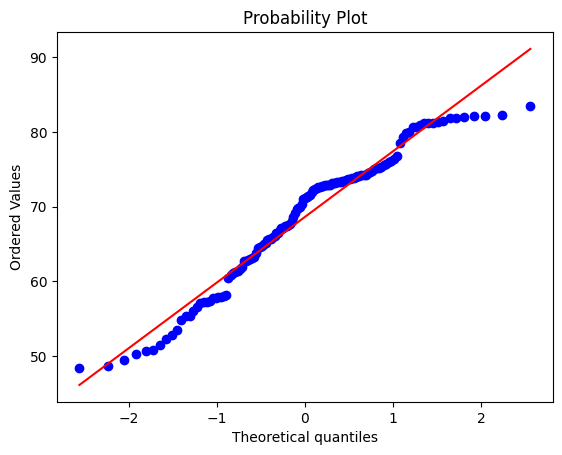

AdultMortality


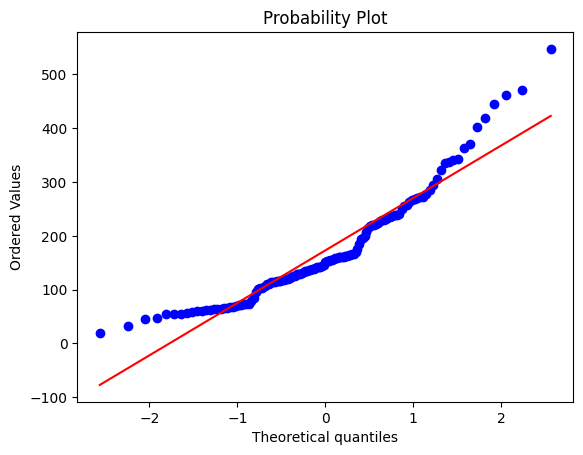

infantdeaths


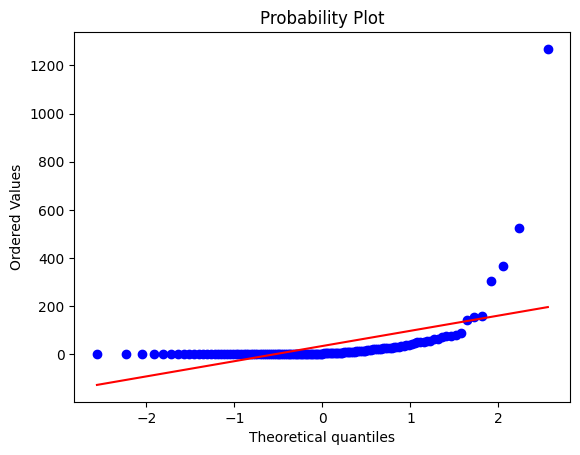

Alcohol


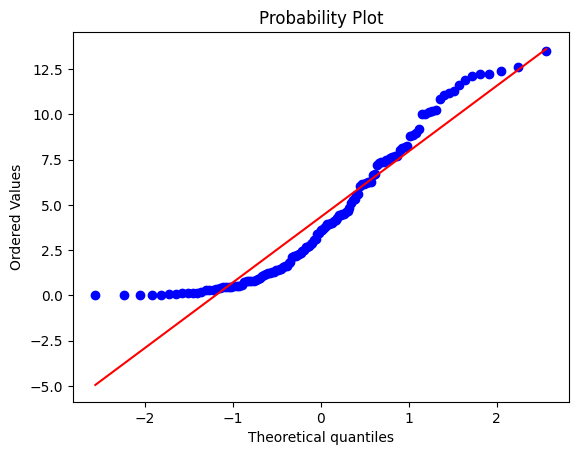

percentageexpenditure


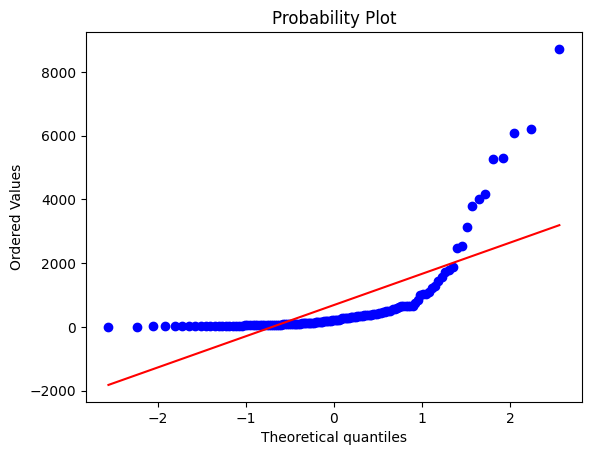

HepatitisB


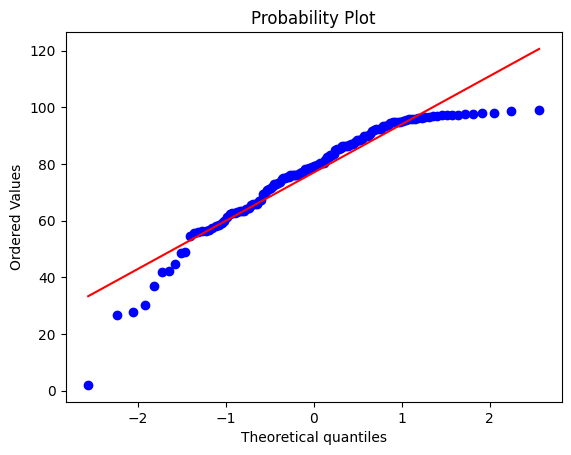

Measles


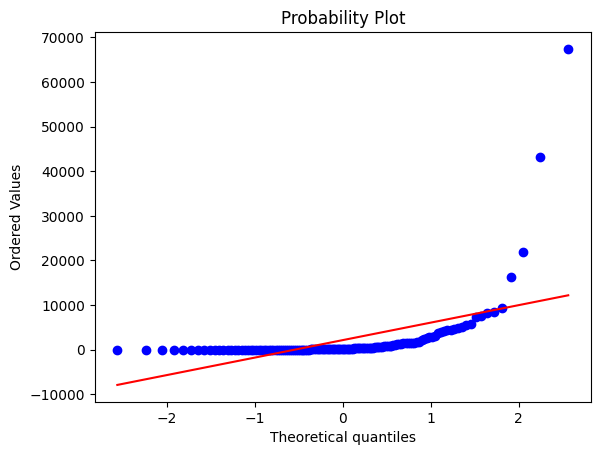

BMI


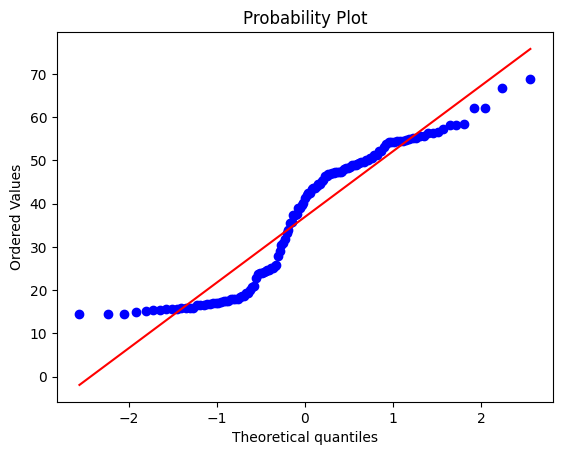

under_fivedeaths


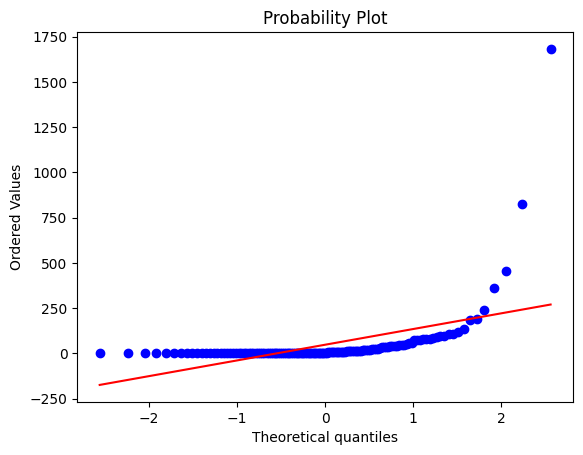

Polio


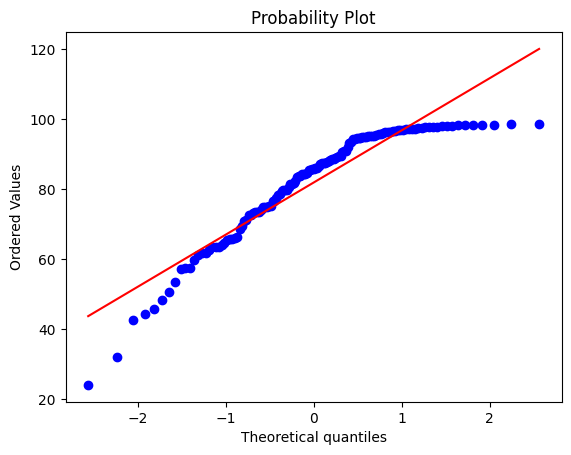

Totalexpenditure


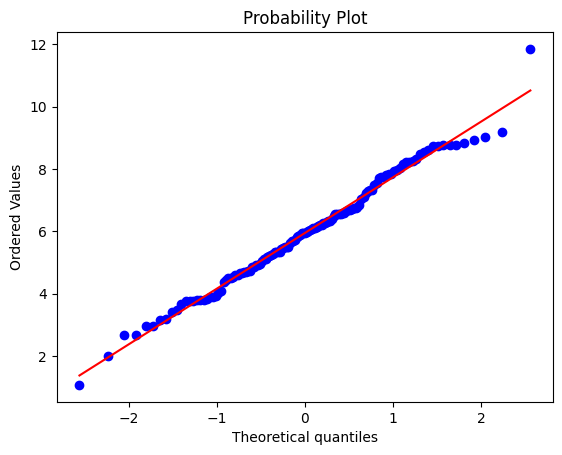

Diphtheria


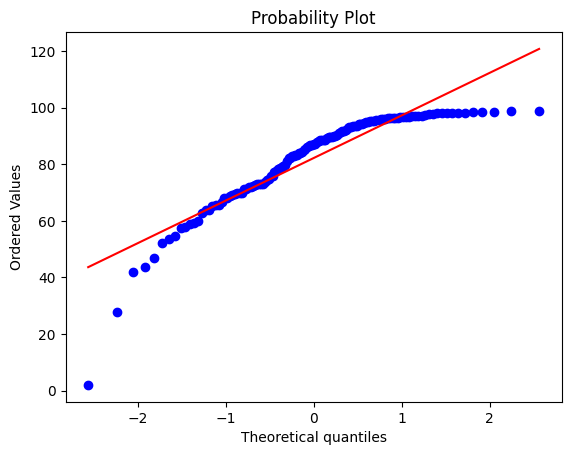

GDP


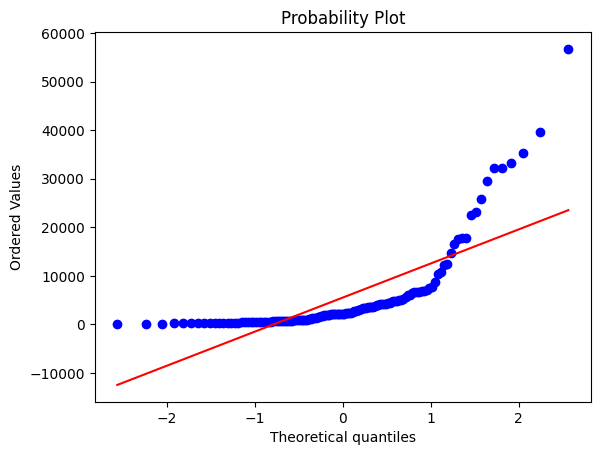

Population


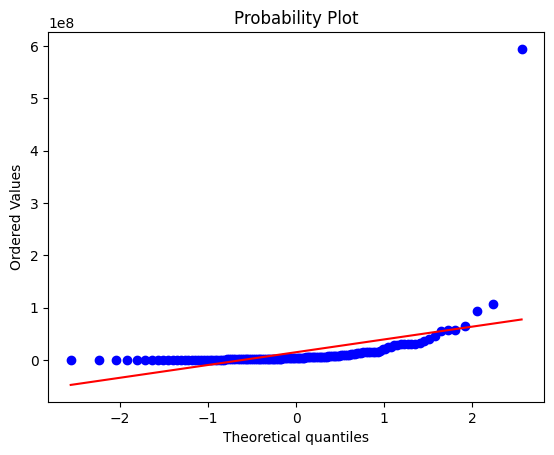

thinness1_19years


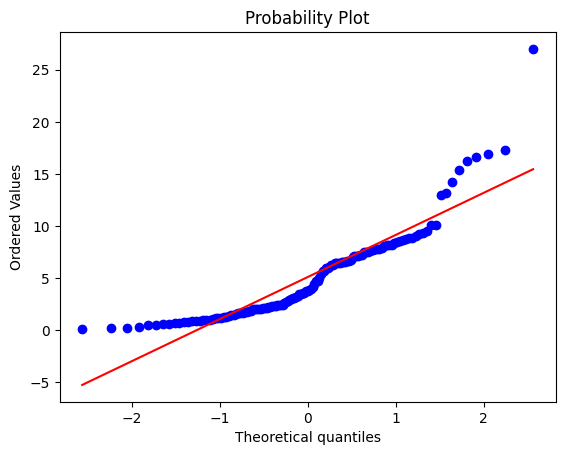

thinness5_9years


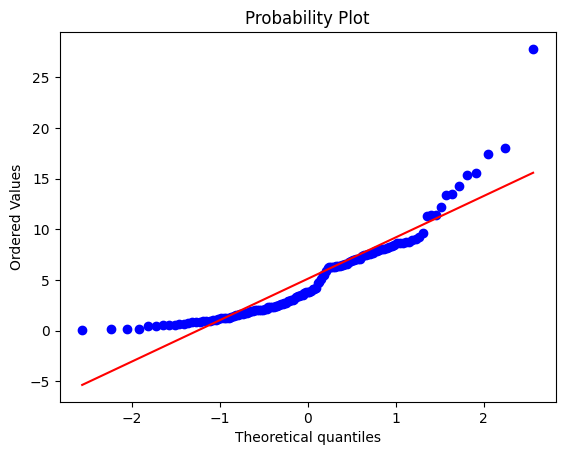

Incomecompositionofresources


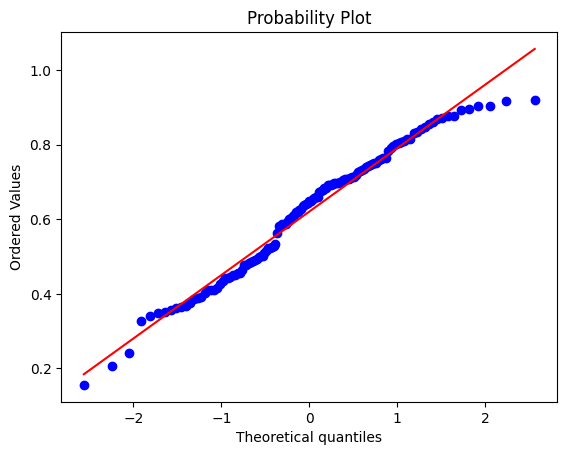

Schooling


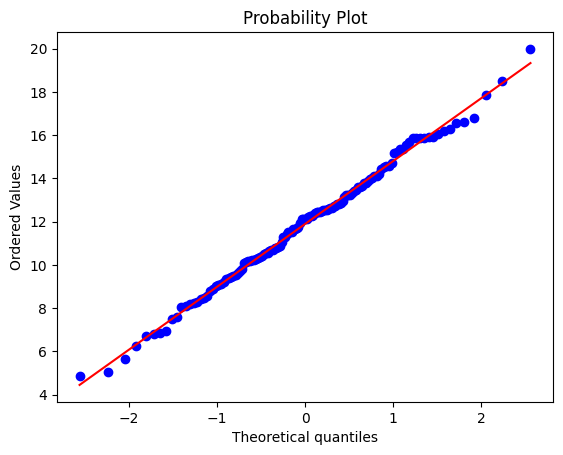

In [24]:
for i in data[var_num].columns:
    measurements = np.random.normal(loc = 20,scale = 5,size=150)
    print(i)
    stats.probplot(data[i], dist="norm",plot=pylab)
    pylab.show()

# Prueba K-cuadrado de D’Agostino’s

In [25]:
for i in data[var_num].columns:
    data2 = data[i].dropna().to_numpy()
    stat,p = normaltest(data2)
    print(i)
    print('stat = %.3f, p = %.3f\n'%(stat,p))
    if p >0.05:
     print('Probablemente se distribuye Normal')
    else:
     print('Probablemente no se distribuye Normal')
    print()

Lifeexpectancy
stat = 7.968, p = 0.019

Probablemente no se distribuye Normal

AdultMortality
stat = 28.854, p = 0.000

Probablemente no se distribuye Normal

infantdeaths
stat = 233.774, p = 0.000

Probablemente no se distribuye Normal

Alcohol
stat = 13.851, p = 0.001

Probablemente no se distribuye Normal

percentageexpenditure
stat = 123.226, p = 0.000

Probablemente no se distribuye Normal

HepatitisB
stat = 33.051, p = 0.000

Probablemente no se distribuye Normal

Measles
stat = 213.214, p = 0.000

Probablemente no se distribuye Normal

BMI
stat = 275.135, p = 0.000

Probablemente no se distribuye Normal

under_fivedeaths
stat = 229.366, p = 0.000

Probablemente no se distribuye Normal

Polio
stat = 26.307, p = 0.000

Probablemente no se distribuye Normal

Totalexpenditure
stat = 0.673, p = 0.714

Probablemente se distribuye Normal

Diphtheria
stat = 54.878, p = 0.000

Probablemente no se distribuye Normal

GDP
stat = 106.734, p = 0.000

Probablemente no se distribuye Normal

Pop

## Graficos de Cajas

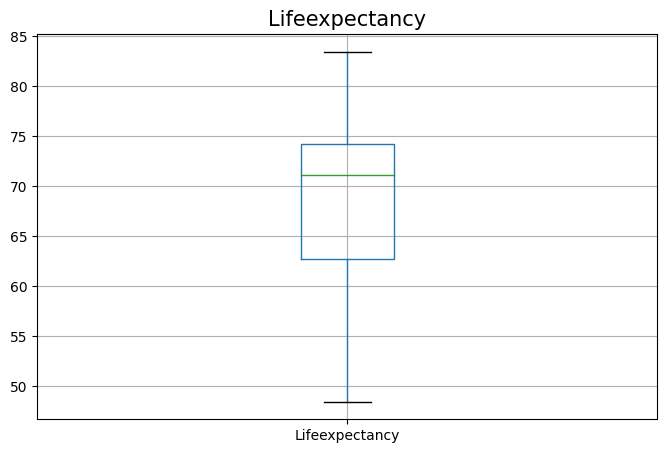

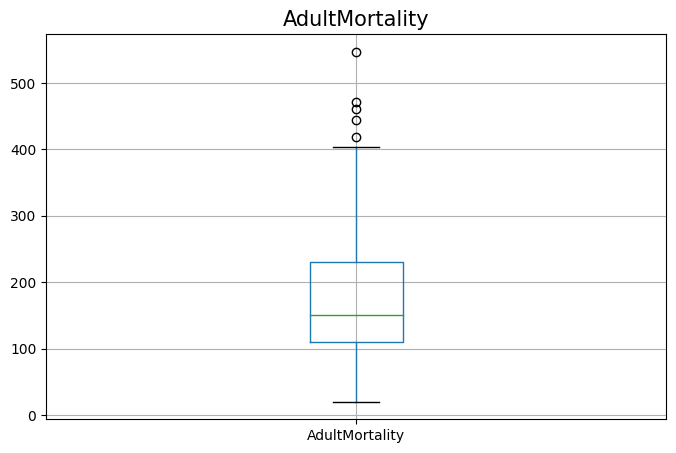

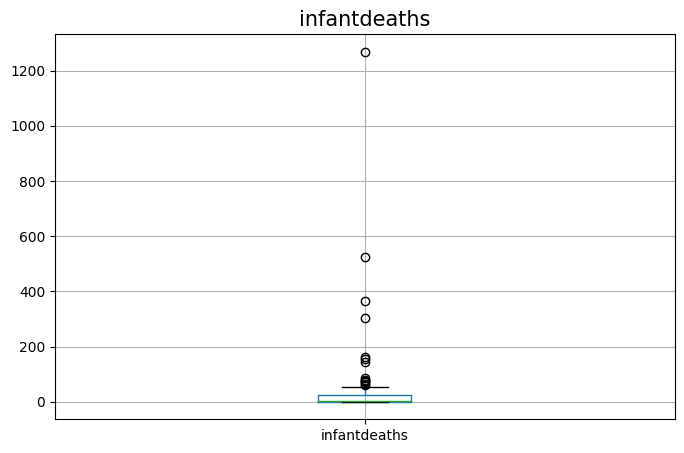

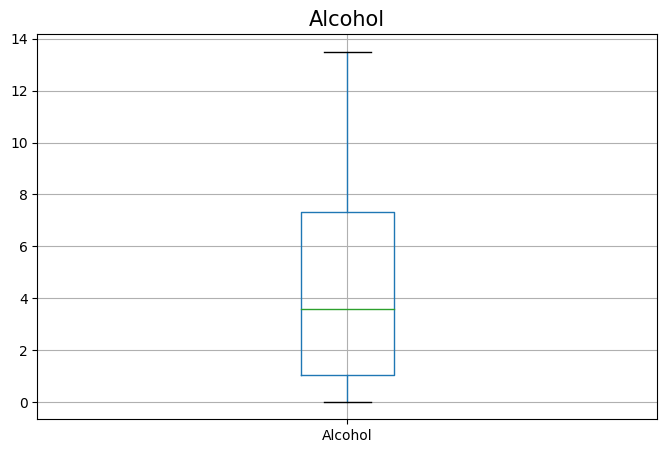

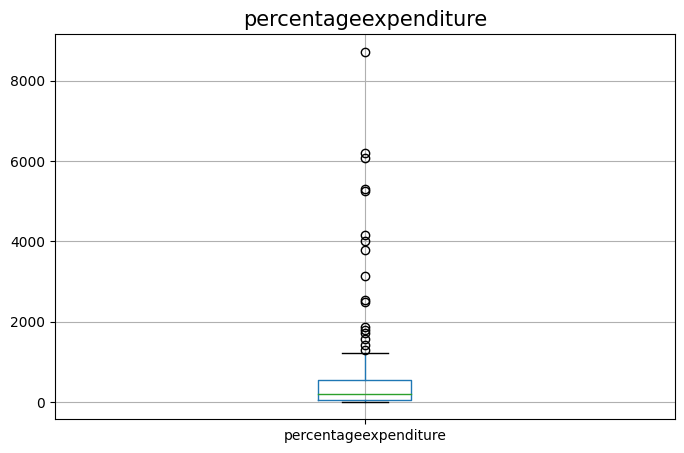

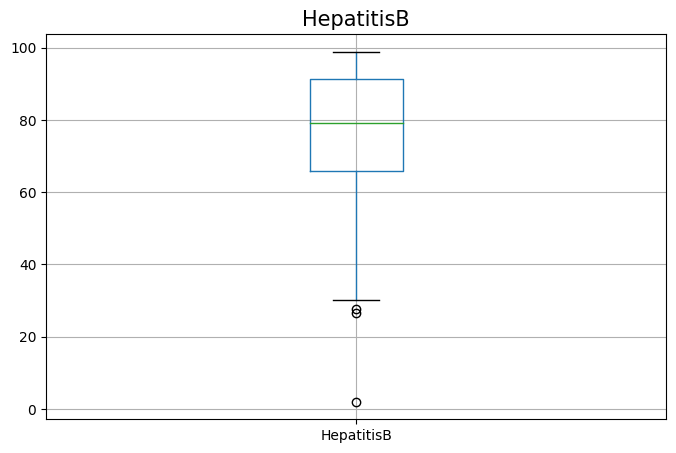

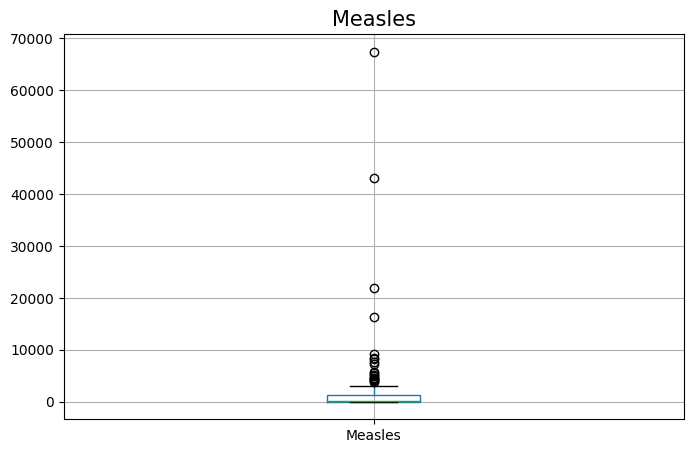

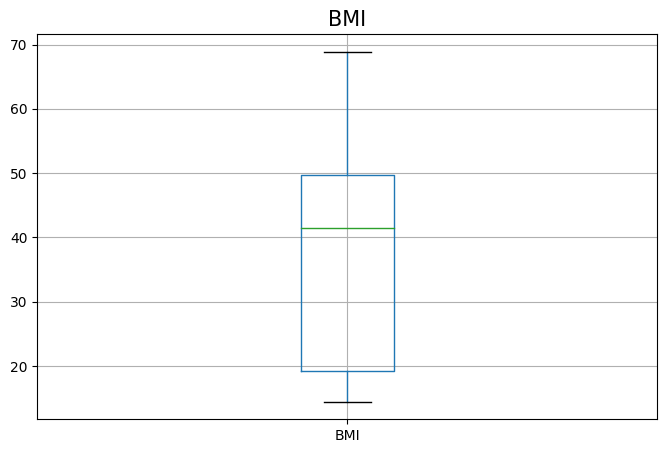

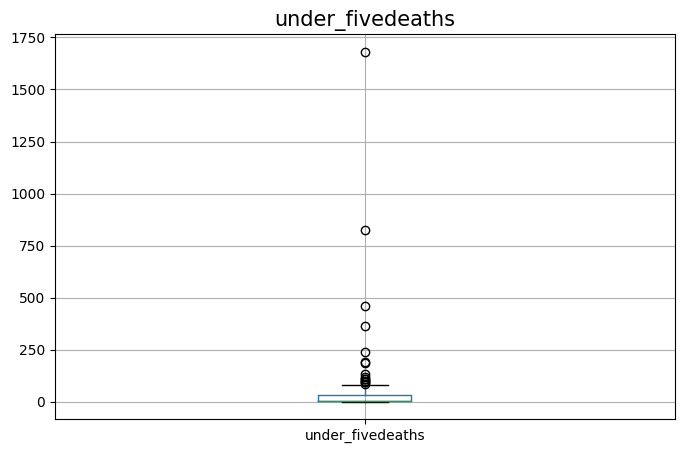

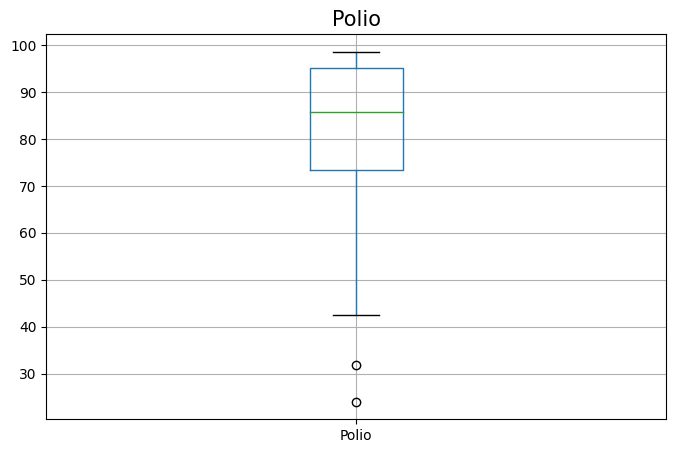

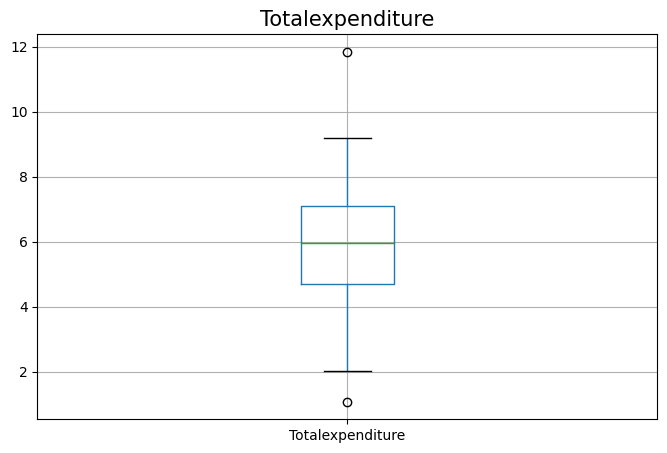

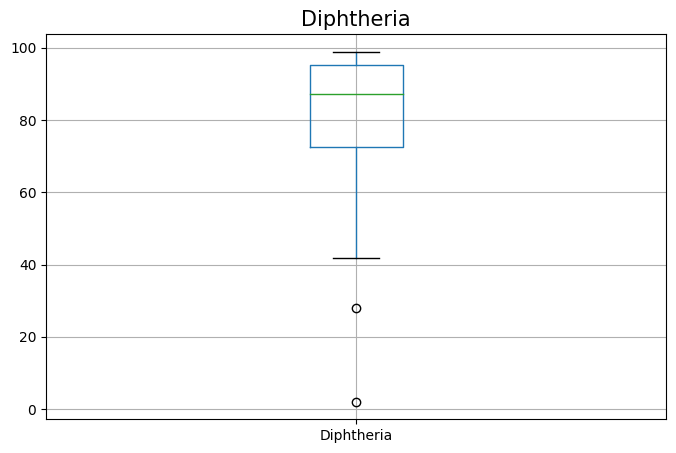

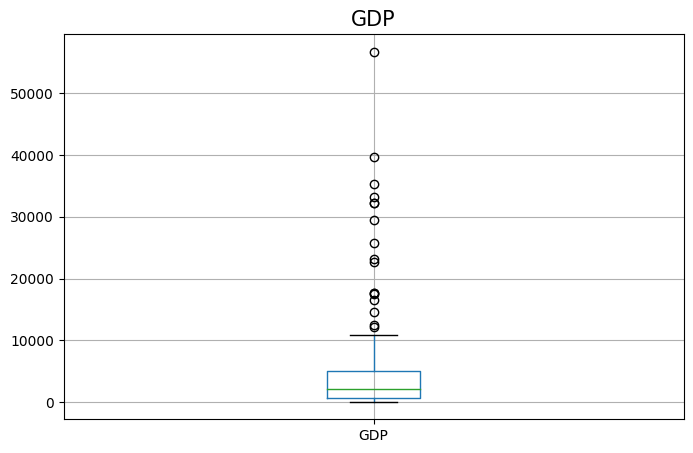

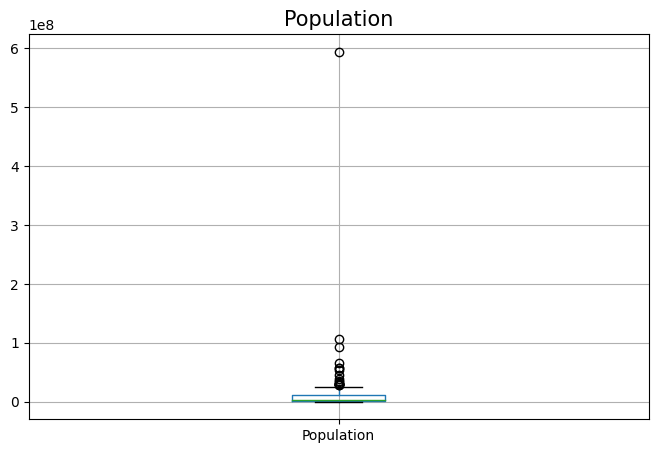

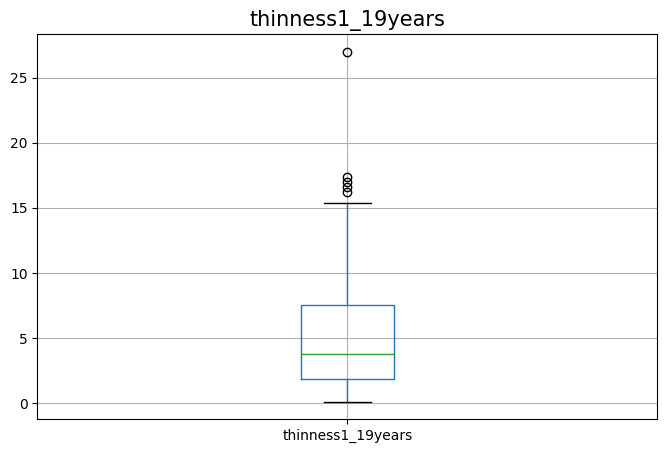

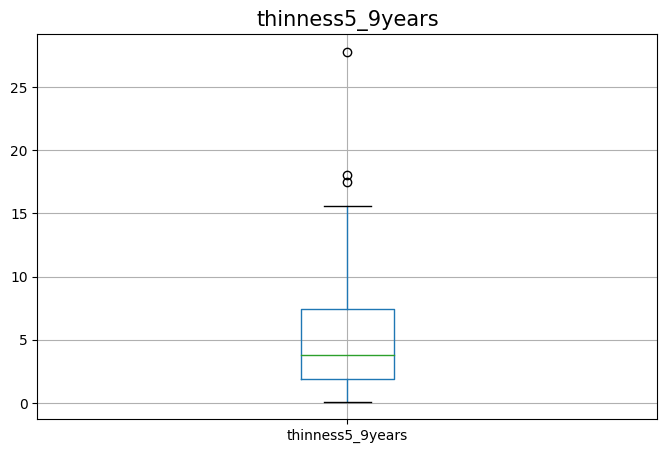

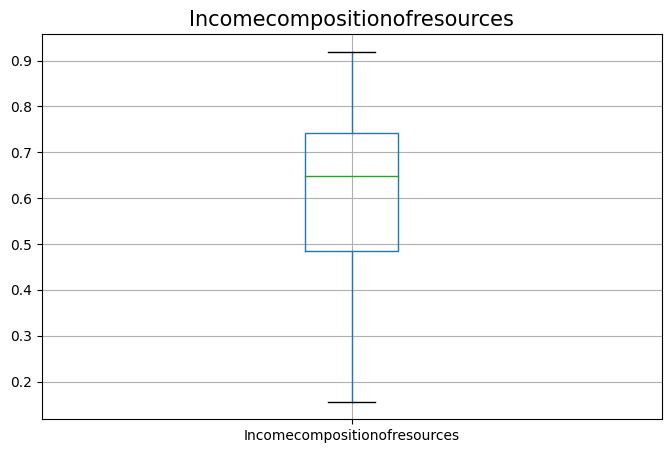

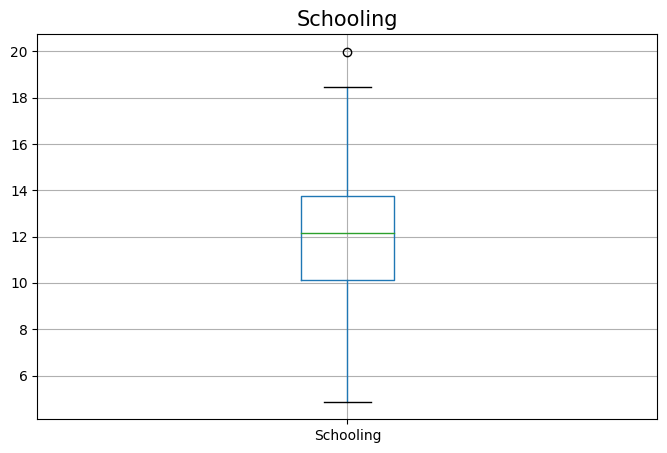

In [26]:
#sns.set()
#genera el gráfico de cajas para las numéricas
for var in data[var_num].columns.to_list():
    fig_dims = (8, 5)
    fig, ax = plt.subplots(figsize=fig_dims)
    data.boxplot(column=[var])
    plt.title(var, size = 15)
    plt.show()

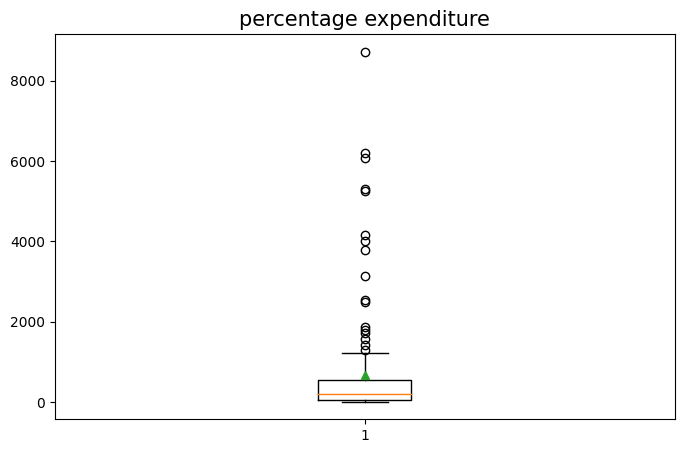

In [27]:
fig_dims = (8, 5)
fig, ax = plt.subplots(figsize=fig_dims)

# para obtener los valores del gráfico(cap, whiskeys, fliers| outliers, maximun, minumun, quantiles)
# guarda en bp los elementos del gráfico
bp = plt.boxplot(data['percentageexpenditure'],showmeans=True)

#título del gráfico
plt.title('percentage expenditure', size = 15)

#muestra el gráfico
plt.show()

In [28]:
#imprime las llaves del diccionario que contiene los elementos del gráfico
bp.keys()

dict_keys(['whiskers', 'caps', 'boxes', 'medians', 'fliers', 'means'])

![image.png](attachment:image.png)

In [29]:
#imprime los valores del gráfico
for key, value in bp.items():
    print(key)
    print([item.get_ydata() for item in value])
    print()

whiskers
[array([56.62812086,  5.04648088]), array([ 551.08285783, 1228.97210428])]

caps
[array([5.04648088, 5.04648088]), array([1228.97210428, 1228.97210428])]

boxes
[array([ 56.62812086,  56.62812086, 551.08285783, 551.08285783,
        56.62812086])]

medians
[array([211.13921861, 211.13921861])]

fliers
[array([6069.17401456, 5257.00180059, 2551.92816721, 5313.06858098,
       1795.0949734 , 4001.60701241, 4160.94961162, 1876.52994181,
       3792.5608153 , 1565.37154872, 3132.94683118, 8722.74809745,
       1423.81653132, 1294.1902535 , 1722.55684898, 2488.19219614,
       6194.892275  ])]

means
[array([683.87701771])]



## Base de Datos solo con outliers

In [30]:
# crea una serie booleana donde "True" indica la presencia de percentage expenditure < 5.04648088 ó > 1228.97210428
filter_outliers = (data['percentageexpenditure'] < 5.04648088) | (data['percentageexpenditure'] > 1228.97210428)

#crea un df solo con los países donde percentage expenditure < 5.04648088 ó > 1228.97210428
df_num_outliers = data.loc[filter_outliers]
df_num_outliers
#len(df_num_outliers)

,Country,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under_fivedeaths,Polio,Totalexpenditure,Diphtheria,GDP,Population,thinness1_19years,thinness5_9years,Incomecompositionofresources,Schooling
6,Australia,Developed,81.9,62.4,1.0,10.2,6069.2,93.4,105.8,54.9,1.4,91.9,8.8,92.0,35391.2,3541690.5,0.7,0.6,0.9,20.0
7,Austria,Developed,81.5,65.8,0.0,12.2,5257.0,80.3,61.8,47.7,0.0,85.5,4.7,86.3,33171.6,6330993.9,1.7,1.9,0.9,15.4
11,Belgium,Developed,80.7,69.9,0.3,11.0,2551.9,72.9,83.9,50.0,1.0,97.7,6.0,97.2,17752.5,2324699.0,0.9,0.8,0.9,16.8
24,Canada,Developing,82.2,66.8,2.0,8.2,5313.1,26.7,135.9,54.3,2.0,84.2,6.6,91.7,29568.9,14844926.8,0.5,0.4,0.9,15.8
32,Croatia,Developed,76.8,60.9,0.0,12.1,1795.1,96.5,9.2,47.4,0.0,96.0,7.8,96.0,12471.4,2312363.9,1.6,1.6,0.8,14.5
40,Estonia,Developing,74.8,158.5,0.0,10.2,1229.0,86.5,3.9,57.2,0.0,94.5,5.9,94.4,10855.7,872838.6,2.0,2.1,0.8,16.2
43,France,Developing,82.2,72.8,3.0,12.4,4001.6,48.9,2828.6,51.3,3.5,98.3,6.6,98.1,25794.8,28976350.8,0.6,0.6,0.9,15.9
46,Germany,Developed,81.2,71.5,2.5,11.6,4160.9,76.7,1432.7,51.3,3.3,94.9,4.1,89.5,23215.1,35895396.5,1.1,1.1,0.9,16.6
48,Greece,Developing,81.2,73.7,0.2,8.8,1876.5,88.5,26.5,58.2,0.5,90.9,9.0,96.5,17538.7,1641363.5,0.8,0.7,0.8,15.9
58,Ireland,Developed,83.4,55.4,0.0,11.3,3792.6,85.2,183.8,49.7,0.0,95.2,8.2,95.2,32225.1,3767073.0,0.3,0.2,0.9,18.5


## Verificar si estos valores influencian los resultados

## Base de Datos sin Outliers

In [31]:
#se crea una base sin los valores atípicos
df_num_no_outliers = data.drop(df_num_outliers.index, axis=0)
df_num_no_outliers
#len(df_num_no_outliers)

,Country,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under_fivedeaths,Polio,Totalexpenditure,Diphtheria,GDP,Population,thinness1_19years,thinness5_9years,Incomecompositionofresources,Schooling
0,Afghanistan,Developing,58.2,269.1,78.2,0.0,35.0,64.6,2362.2,15.5,107.6,48.4,8.3,52.3,340.0,9972259.8,16.6,15.6,0.4,8.2
1,Albania,Developing,75.2,45.1,0.7,4.8,193.3,98.0,53.4,49.1,0.9,98.1,5.9,98.1,2119.7,696911.6,1.6,1.7,0.7,12.1
2,Algeria,Developing,74.2,102.8,20.3,0.4,300.3,76.5,647.0,48.9,23.4,93.2,4.9,93.4,3261.3,24124739.3,6.0,5.9,0.7,13.2
3,Angola,Developing,50.7,362.8,76.6,7.6,174.4,71.0,3925.6,18.4,118.8,70.9,3.7,64.0,2935.8,10107848.4,9.0,8.9,0.5,9.5
4,Argentina,Developing,75.2,100.4,10.0,8.0,838.2,80.3,2.0,54.5,11.2,94.5,6.5,93.7,6932.5,20847453.5,1.1,0.9,0.8,16.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,Uruguay,Developing,76.0,120.2,0.6,6.2,663.3,94.3,0.0,52.2,0.8,94.2,8.8,88.7,6637.1,2327785.7,1.6,1.6,0.8,15.2
129,Uzbekistan,Developing,68.0,184.5,21.4,1.6,47.5,95.4,247.0,34.0,24.9,98.5,5.7,98.3,558.8,894155.3,3.1,3.2,0.6,11.8
130,Vanuatu,Developing,71.3,146.2,0.0,0.8,301.1,55.6,19.7,43.7,0.0,66.3,3.9,58.7,2114.5,129538.4,1.6,1.5,0.4,10.6
131,Zambia,Developing,57.2,370.0,30.5,2.1,121.4,75.9,3113.3,16.9,46.9,59.6,5.1,75.9,1009.5,7338203.1,6.7,6.6,0.5,11.7


## Grafico con Outliers

Text(0.5, 1.0, 'Gráfico de dispersión entre Porcentaje de gastos y la escolaridad (con outliers)')

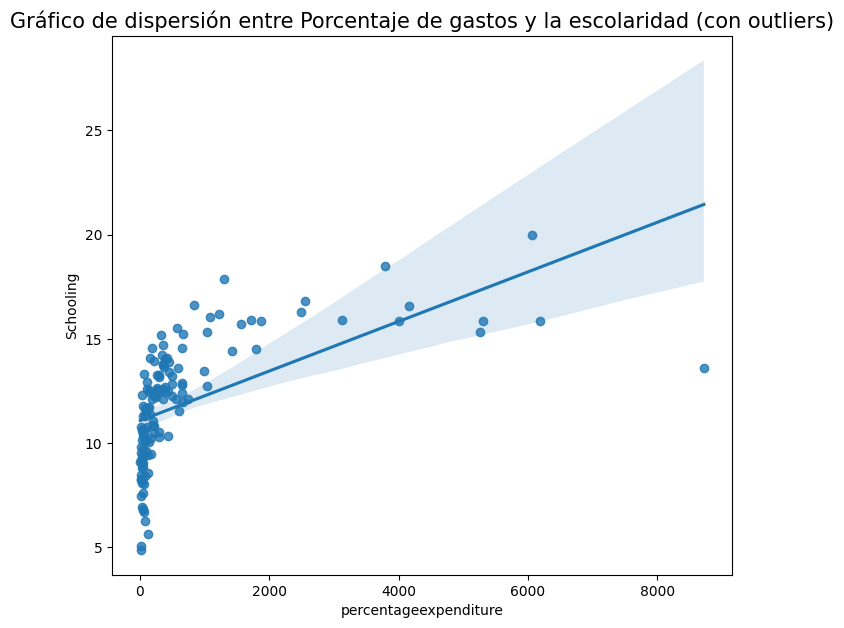

In [32]:
#el 1er argumento controla el ancho y el 2do la altura
fig_dims = (8, 7)
fig, ax = plt.subplots(figsize=fig_dims)

#general el gráfico
sns.regplot(data = data, x = "percentageexpenditure", y = "Schooling", ax=ax)

plt.title('Gráfico de dispersión entre Porcentaje de gastos y la escolaridad (con outliers)', size = 15)
#plt.xlabel('Media del Radio', size = 20)
#plt.ylabel('Suma de cuadrados de las distancias', size = 20)

##Grafico sin Outliers

Text(0.5, 1.0, 'Gráfico de dispersión entre Porcentaje de gastos y la escolaridad (con outliers) (sin outliers)')

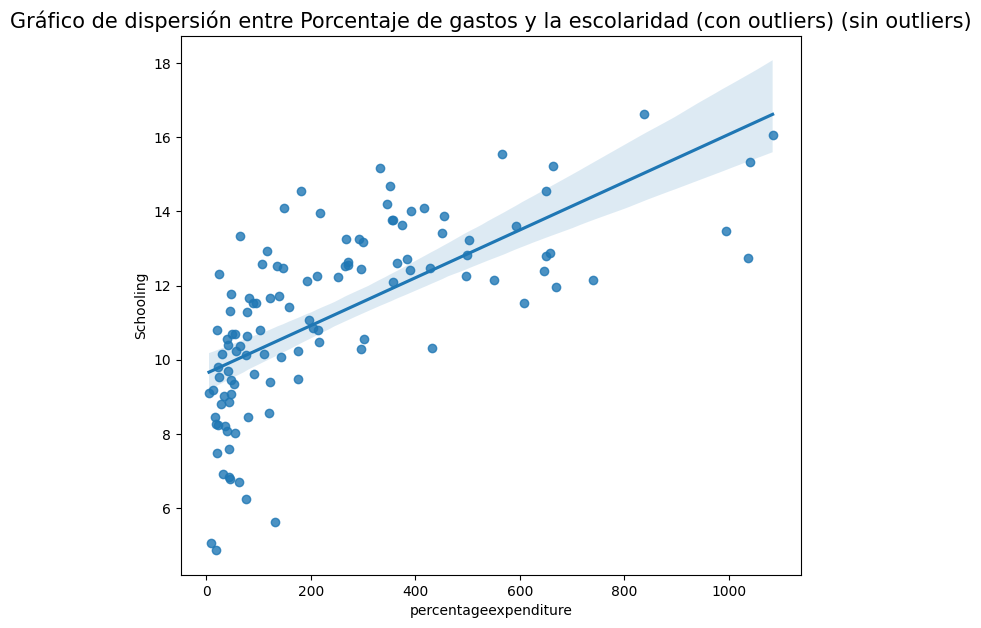

In [33]:
#el 1er argumento controla el ancho y el 2do la altura
fig_dims = (8, 7)
fig, ax = plt.subplots(figsize=fig_dims)

#general el gráfico
sns.regplot(data = df_num_no_outliers, x = "percentageexpenditure", y = "Schooling", ax=ax)

plt.title('Gráfico de dispersión entre Porcentaje de gastos y la escolaridad (con outliers) (sin outliers)', size = 15)
#plt.xlabel('Media del Radio', size = 20)
#plt.ylabel('Suma de cuadrados de las distancias', size = 20)

Al comparar la linea ajustada a la nube de puntos con outliers y sin outliers, se observa que la pendiente de la linea no cambia, por lo tanto, eliminar o no a los outliers da igual, se pueden dejar estos outliers en la base.

#Correlaciones entre las variables numéricas

In [34]:
#genera la Matriz de Correlacion
round(data[var_num].corr(),2)

,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under_fivedeaths,Polio,Totalexpenditure,Diphtheria,GDP,Population,thinness1_19years,thinness5_9years,Incomecompositionofresources,Schooling
Lifeexpectancy,1.0,-0.9,-0.2,0.5,0.6,0.3,-0.1,0.7,-0.2,0.6,0.3,0.5,0.6,-0.0,-0.5,-0.5,0.8,0.8
AdultMortality,-0.9,1.0,0.1,-0.3,-0.4,-0.1,0.0,-0.6,0.1,-0.4,-0.1,-0.3,-0.4,-0.0,0.4,0.4,-0.6,-0.6
infantdeaths,-0.2,0.1,1.0,-0.1,-0.1,-0.3,0.7,-0.3,1.0,-0.2,-0.2,-0.2,-0.1,0.9,0.5,0.5,-0.1,-0.2
Alcohol,0.5,-0.3,-0.1,1.0,0.6,0.2,-0.1,0.5,-0.1,0.4,0.3,0.4,0.6,-0.0,-0.5,-0.5,0.7,0.7
percentageexpenditure,0.6,-0.4,-0.1,0.6,1.0,0.0,-0.1,0.4,-0.1,0.3,0.3,0.3,0.9,-0.0,-0.4,-0.4,0.6,0.6
HepatitisB,0.3,-0.1,-0.3,0.2,0.0,1.0,-0.2,0.2,-0.3,0.7,0.2,0.8,0.0,-0.2,-0.2,-0.2,0.2,0.3
Measles,-0.1,0.0,0.7,-0.1,-0.1,-0.2,1.0,-0.2,0.7,-0.1,-0.2,-0.1,-0.1,0.5,0.3,0.3,-0.1,-0.1
BMI,0.7,-0.6,-0.3,0.5,0.4,0.2,-0.2,1.0,-0.3,0.4,0.4,0.4,0.5,-0.1,-0.7,-0.7,0.7,0.7
under_fivedeaths,-0.2,0.1,1.0,-0.1,-0.1,-0.3,0.7,-0.3,1.0,-0.2,-0.2,-0.2,-0.1,0.9,0.5,0.5,-0.2,-0.2
Polio,0.6,-0.4,-0.2,0.4,0.3,0.7,-0.1,0.4,-0.2,1.0,0.3,0.9,0.4,-0.1,-0.3,-0.3,0.5,0.6


Hacer una tabla donde coloques las variables que tengan correlacion significativa

##Mapa de calor de las Correlaciones

(18.5, -0.5)

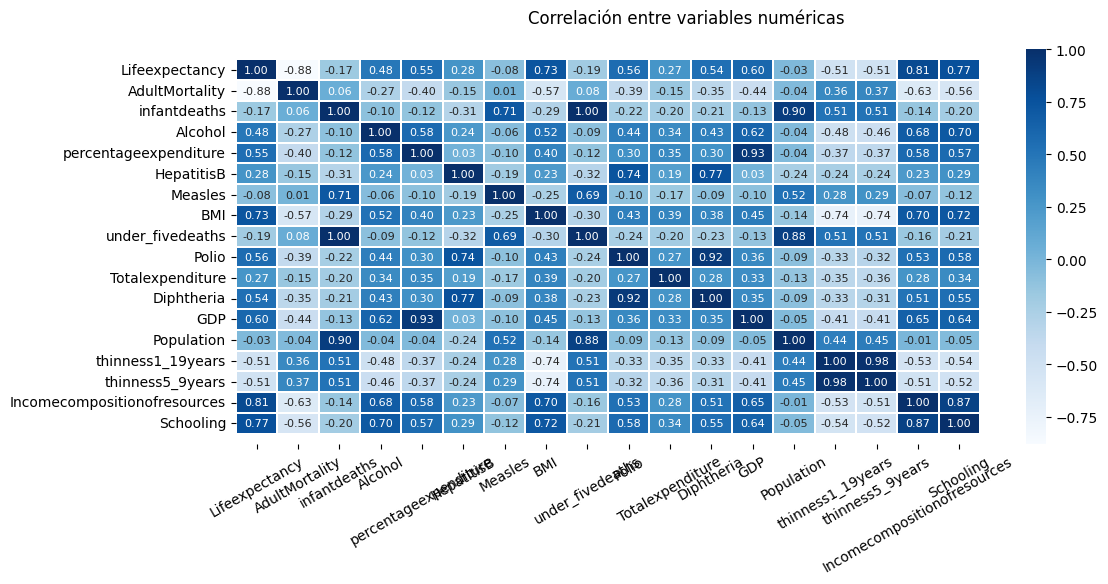

In [35]:
#controla el ancho (valor izquierdo) y el alto (derecho) del gráfico
f, ax = plt.subplots(figsize=(12,5))

#genera la matriz de correlaciones
corr = data[var_num].corr()

#gebera el mapa de calor, donde annot: coloca valores, cmap:color, fmt:formato de números
hm = sns.heatmap(round(corr,2), annot=True, ax=ax, cmap='Blues',fmt='.2f',linewidths=.1,annot_kws={'size': 8})

#controla la separación del título con el gráfico
f.subplots_adjust(top=0.9)

#título del gráfico
t= f.suptitle('Correlación entre variables numéricas', fontsize=12)

#controla la rotacion de las etiquetas en "x"
plt.xticks(rotation=30)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

##Variables categóricas

In [36]:
#imprime la cantidad de variables categóricas en la muestra
print('Número de variables categóricas: ', len(var_cat))

# visualiza las variables numéricas
data[var_cat].head()

Número de variables categóricas:  2


,Country,Status
0,Afghanistan,Developing
1,Albania,Developing
2,Algeria,Developing
3,Angola,Developing
4,Argentina,Developing


##Descripción de categóricas

In [37]:
#genera tabla resumen de las categóricas
data[var_cat].describe()

,Country,Status
count,133,133
unique,133,2
top,Afghanistan,Developing
freq,1,114


## Perfil resumido de variables categóricas

In [38]:
#genera lista de variables que se usarán para obtener el perfil de muestra
lista_var = var_cat

#genera lista de categorias mas frecuentes de cada variable
lista_cat = []
for var in lista_var:
    lista_cat.append(statistics.mode(data[var].dropna()))

#genera lista de porcentajes maximos de categorias de cada variable
lista_porc = []
for var in lista_var:
    lista_porc.append(max(round(data[var].value_counts(normalize=True)*100,1)))

#crea lista de nombres que tendrá el DF final del perfil de la muestra
nombre_vars = ['Variable','Categoría más frecuente','Porcentaje']

#zipea todas las listas creadas anteriormente y crea tambien una lista de ellas
zipeo_listas = zip(lista_var,lista_cat,lista_porc)

#coloca las listas zipeadas y los nombres de las columnas en un DataFrame
perfil_muestra = pd.DataFrame(zipeo_listas, columns = nombre_vars)
#se ordena el DF segun los porcentajes (descendente) y se alinean los datos a la derecha.
perfil_muestra.sort_values(["Porcentaje"], ascending = False).style.set_properties(**{'text-align': 'left'})
#perfil_muestra.to_excel('Perfil_resumido_muestra.xlsx')

,Variable,Categoría más frecuente,Porcentaje
1,Status,Developing,85.700000
0,Country,Afghanistan,0.800000


In [39]:
data.columns

Index(['Country', 'Status', 'Lifeexpectancy', 'AdultMortality', 'infantdeaths',
       'Alcohol', 'percentageexpenditure', 'HepatitisB', 'Measles', 'BMI',
       'under_fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria', 'GDP',
       'Population', 'thinness1_19years', 'thinness5_9years',
       'Incomecompositionofresources', 'Schooling'],
      dtype='object')

In [40]:
data['Status'].value_counts()

,count
Status,
Developing,114
Developed,19


##FUNCION QUE GENERA LAS PRUEBAS CHI-CUADRADO

In [41]:
######### FUNCION QUE GENERA LAS PRUEBAS CHI-CUADRADO ########
#round(1 - stats.chi2.cdf(1.06, 1),3)


def chi2_y_cramer(df, nombre_variable, variable_id = None):
  """Esta funcion toma como 1er argumento un dataframe "df" que tiene solo variables categoricas, como segundo argumento el nombre de la variable
      etiqueta (debe estar entre comillas) y como 3er argumento el nombre del campo ID (entre comillas)
      para calcular los valores de CHI cuadrado y V de Cramer. Esta función devolve
      un dataframe con las columnas index= variables, chicuadrado, V de Cramer y la afirmacion
      existe relacion entre las variables y la etiqueta"""


  # este es una sintaxis para controlar los errores
  try:
    vars_categoricas = df.select_dtypes('object')
  except:
    print("Problemas en la separacion de las categoricas")


  #Se crea el diccionario base vacio que se va a imprimir en un dataframe
  diccionario = {'variable': [], 'CHI2': [], 'V-Cramer' : [],'valor_p' : [], 'relacion' : []}

  #itera cada columna de la BD que contiene las variables categoricas
  for variable in vars_categoricas.columns:
    #Se excluye la variable codcli ya que es una columna ID
    if variable != variable_id:


      #Se crea una tabla de contingencia de cada variable categorica VS la Etiqueta, añadiendo los totales
      tabla_contingencia_total2 = pd.crosstab(index= vars_categoricas[variable], columns=vars_categoricas[nombre_variable], margins=True)

      #Se crea una tabla de contingencia de cada variable categorica VS la Etiqueta sin los totales
      tabla_contingencia2 = pd.crosstab(index=vars_categoricas[variable], columns=vars_categoricas[nombre_variable], margins=False)

      #Se realiza la prueba Chi-cuadrado con la tabla de contingencia con los totales
      resultados_chi22 = chi2_contingency(tabla_contingencia_total2)

      #Se guarda el valor del estadístico X2
      X2 = resultados_chi22[0]

      #se calculan los grados de libertad
      gl = (tabla_contingencia2.shape[0]-1)*(tabla_contingencia2.shape[1]-1)

      #Se obtiene el Valor-p de la prueba
      valor_p = round(1 - chi2.cdf(X2, gl),3)

      #Se guarda en "n" el total de individuos en la tabla de contigencia
      n = np.sum(np.array(tabla_contingencia2))

      #Se calcula parte del denominador del indicador V-Cramer (min(f,c) -1)
      minDim = min(tabla_contingencia2.shape) -1

      #Se calcula el indicador de asociación V-Cramer
      V = np.sqrt(X2 / (minDim * n))

      #crear la variable si existe relacion o no
      def define_si_relacion(valor):

        if valor > 0.01:
          return 'No'
        else:
          return 'Si'
      #Se agrega al diccionario vacio inicialmente creado la informacion de variables y elementos de la prueba Chi-cuadrado
      diccionario['variable'].append(variable)
      diccionario['CHI2'].append(round(resultados_chi22[0], 2))
      diccionario['V-Cramer'].append(round(V, 3))
      diccionario['valor_p'].append(round(valor_p, 3))
      diccionario['relacion'].append(define_si_relacion(valor_p))

  # Convertir el diccionario a un DF

  df = pd.DataFrame(diccionario)

  #Exporta to Excel y lo guarda en el directorio que este activo
  #df.to_excel('Tabla_chi2_categoricas.xlsx')
  return df

############ FUNCION QUE GENERA GRÁFICOS APILADOS 100% DE CATEGORICAS VS ETIQUETA ##############################################################



def grafica_categoricas_vs_etiqueta(df_tabla):
  df_tabla.plot(kind='bar', stacked=True, figsize=(15,8), )
  plt.legend(loc='best', bbox_to_anchor=(1.0, 0.5))
  plt.title(df_tabla.index.name  + ' VS '+ df_tabla.columns.name, fontsize=20)
  plt.show()


def crear_tabla_porcentaje_etiqueta(df, indice, columna, nombre_etiqueta):

  tabla = pd.pivot_table(data=df, values=indice, index = columna, columns=df[nombre_etiqueta], aggfunc='count')
  tabla['total'] = tabla['Developed'] + tabla['Developing']
  tabla['%_Developed'] = np.round(100 *tabla['Developed'] / tabla['total'],2)
  tabla['%_Developing'] = np.round(100 * tabla['Developing'] / tabla['total'],2)
  tabla.drop(['Developed','Developing','total'], axis=1, inplace=True)
  return tabla

######################################################## FUNCION QUE GENERA GRÁFICOS DE BARRAS DE LOS PROMEDIOS DE NUMERICAS VS ETIQUETA ##########################################################

def grafica_numerica_vs_etiqueta(df_numericas, df_target):
  """Esta funcion grafica el promedio de las variables numericas segun las categorias de la variable etiqueta.
  El argumento df_numericas representa un dataframe que contiene solo las variables numericas en estudio
  y df_target representa la variable independiente o etiqueta que se quiere predecir."""

  df_nuevo = pd.concat([df_numericas, df_target], axis=1)

  for columna in df_numericas.columns:
    sns.set()
    fit, ax = plt.subplots(figsize=(6, 6))
    sns.barplot(x=df_target, y=columna , data=df_nuevo, capsize=0.2, ax=ax, ci= None)

# show the mean
    for p in ax.patches:
      ax.annotate(f'mean:\n{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    plt.xlabel(df_target.name.replace('_',' '))
    plt.ylabel(columna.replace('_',' '))
    plt.title(columna.replace('_',' ').upper() + ' VS. ' + df_target.name.replace('_',' ').upper(),fontweight='bold')
    plt.show()
    print("\n"*5)


######################################################## FUNCION QUE GENERA TABLAS ANOVAS ENTRE NUMERICAS VS ETIQUETA ################################################

def crear_tablas_anovas(df_numericas, df_etiqueta):
  """Esta funcion genera la tabla de resultados de anovas entre las variables numericas y la etiqueta"""
  #Se concatena la BD de las numericas y la variable Etiqueta
  df_numericas_y_etiqueta = pd.concat([df_numericas,df_etiqueta], axis=1)


  #Crea la plantilla del DataFrame
  diccionario = {'variable': [],'F' : [], 'valor_p' : []}

  for variable in df_numericas_y_etiqueta.columns:

    if variable != df_etiqueta.name:
      #Crea el modelo ANOVA
      concatenar_variable_etiqueta = str(df_numericas_y_etiqueta[variable].name+ ' ~ ' + df_etiqueta.name)
      mod = ols(concatenar_variable_etiqueta, data = df_numericas_y_etiqueta).fit()

      #Crea tabla con los resultados del ANOVA
      aov_table = sm.stats.anova_lm(mod, type=2)

      diccionario['variable'].append(variable)
      diccionario['F'].append(round(aov_table.F[0],3))
      diccionario['valor_p'].append(round(aov_table['PR(>F)'][0],3))
      # print(concatenar_variable_etiqueta)
      # print(aov_table.loc['Residual','sum_sq'])
      #aov_table
  df_anova = pd.DataFrame(diccionario)
  return df_anova

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




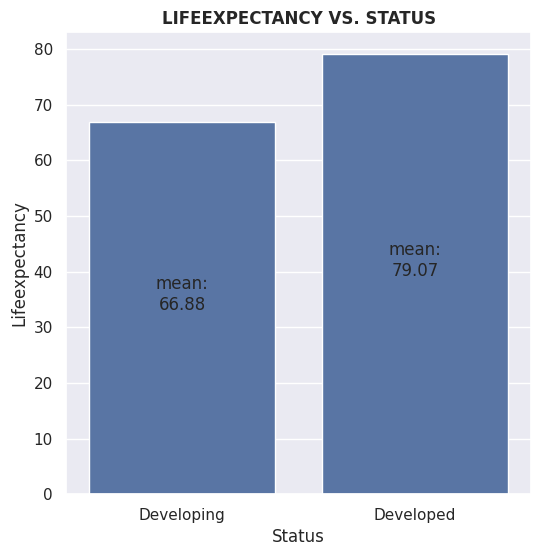

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




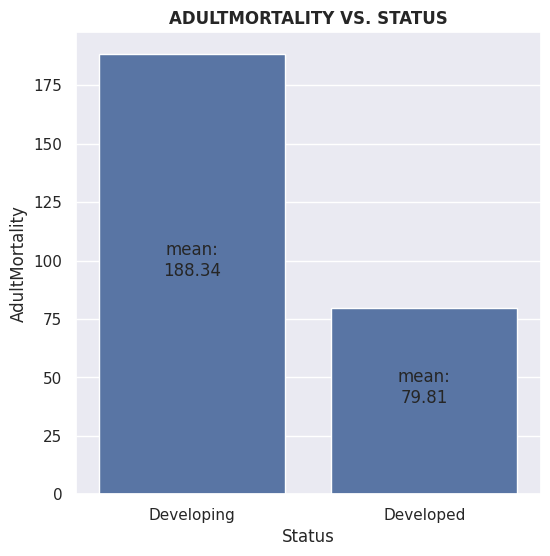

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




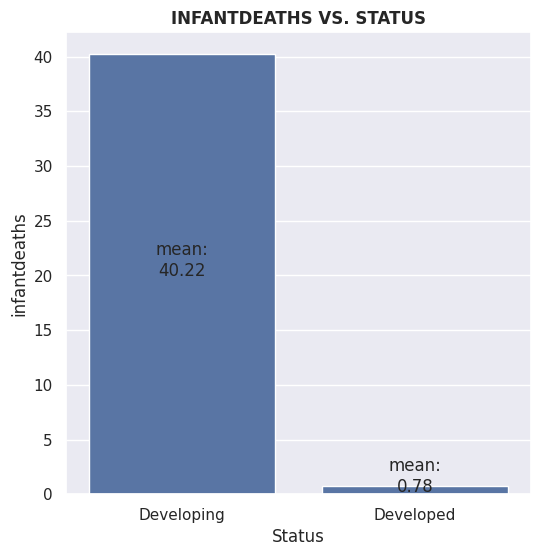

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




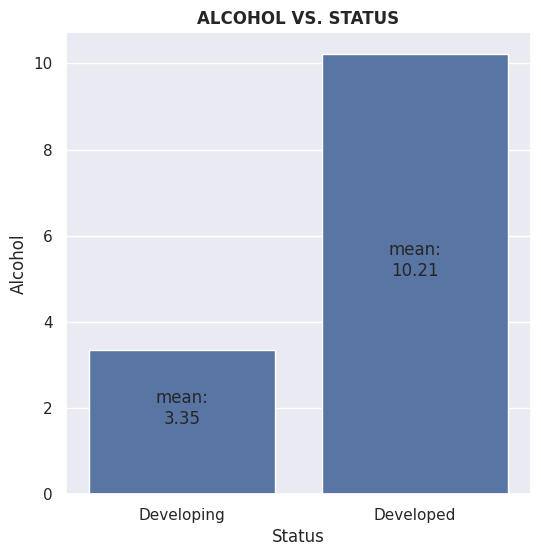

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




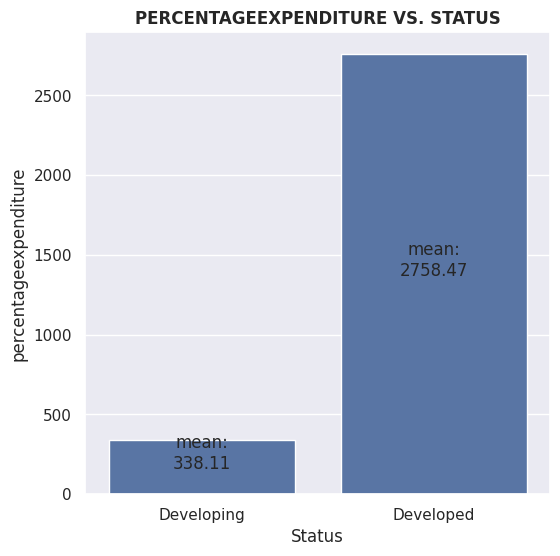

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




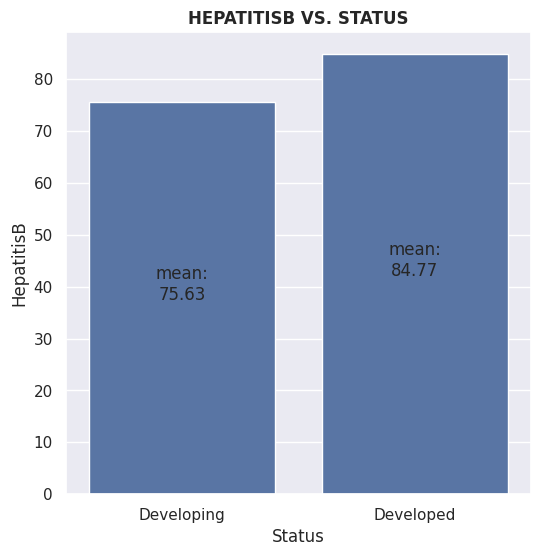

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




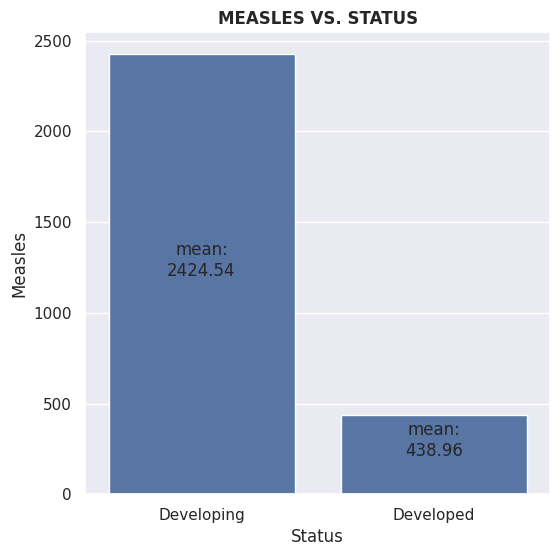

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




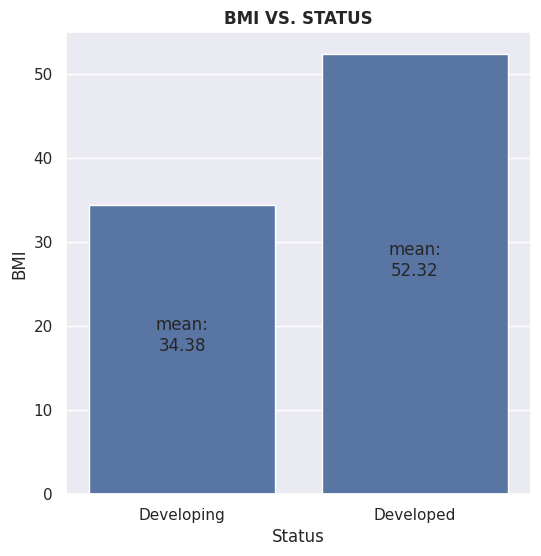

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




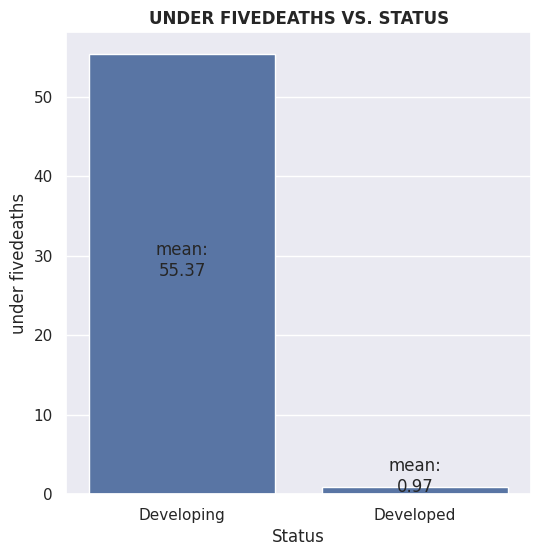

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




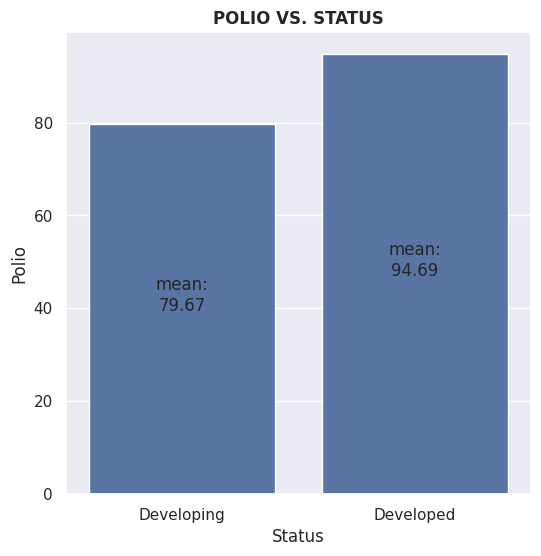

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




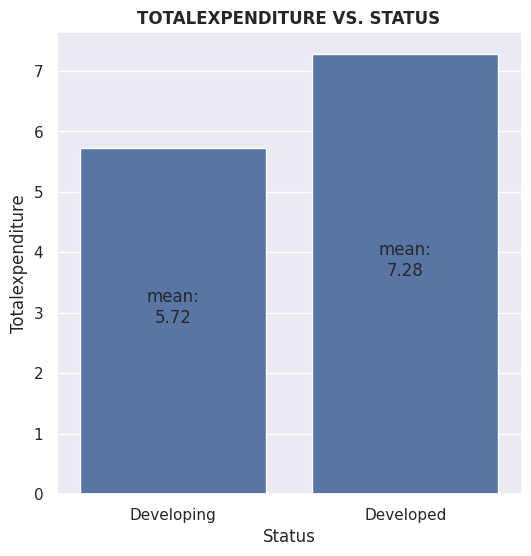

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




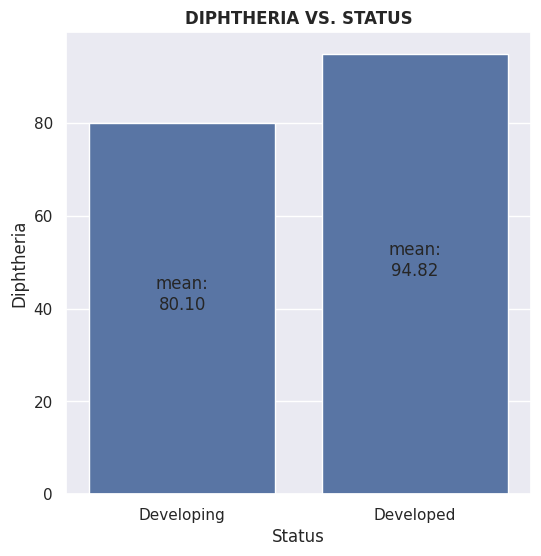

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




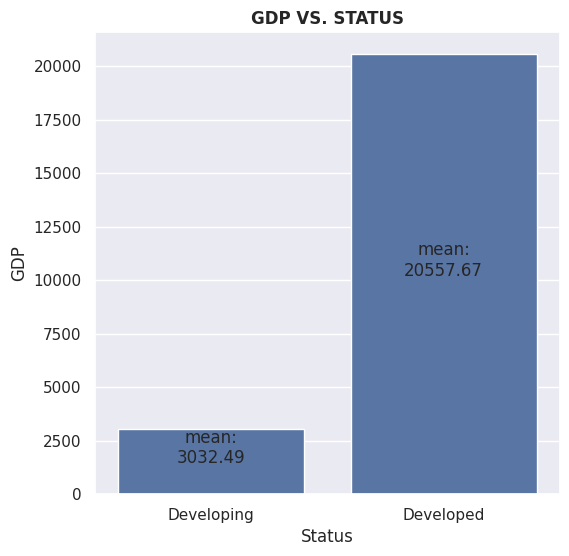

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




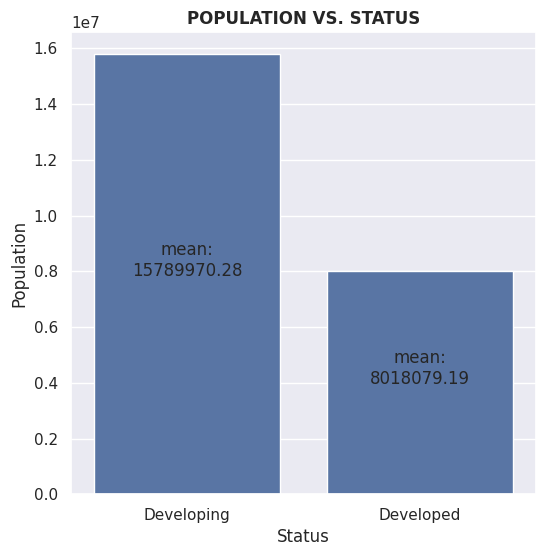

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




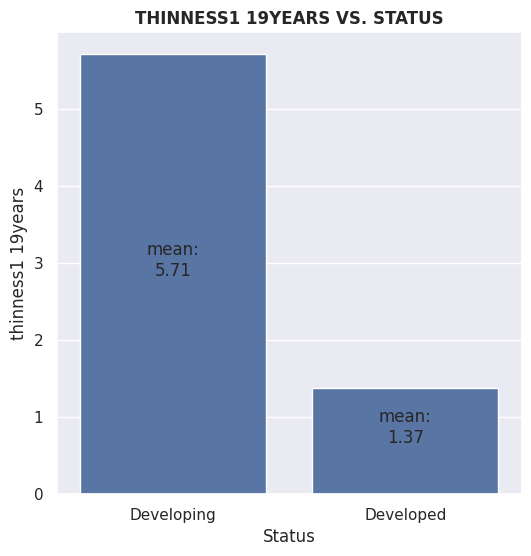

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




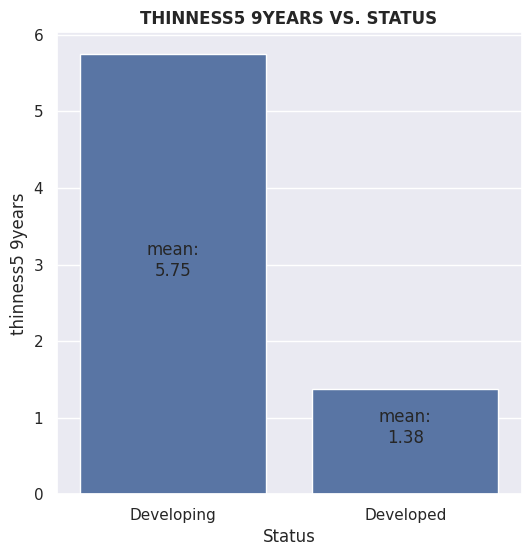

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




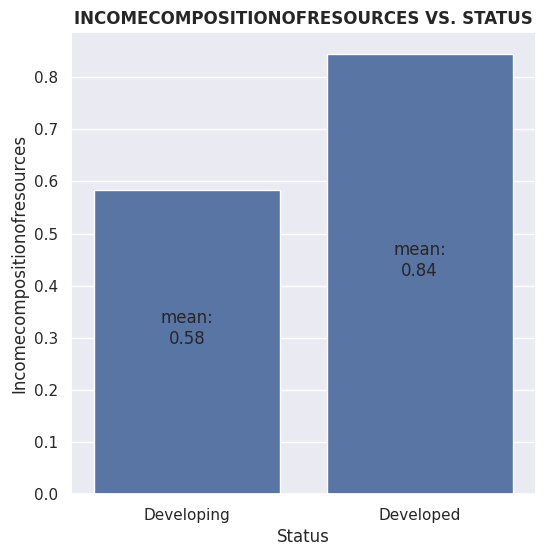

<ipython-input-41-a103d9f51b04>:110: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




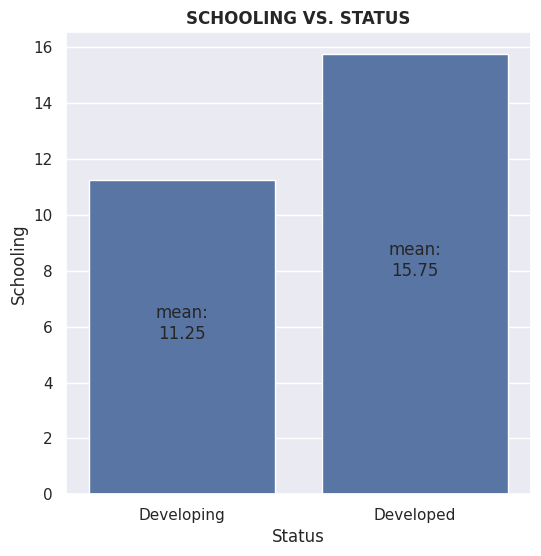

In [42]:
grafica_numerica_vs_etiqueta(data[var_num], data.Status)

In [43]:
df_anova = crear_tablas_anovas(data[var_num], data.Status)
df_anova

<ipython-input-41-a103d9f51b04>:145: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-41-a103d9f51b04>:146: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-41-a103d9f51b04>:145: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-41-a103d9f51b04>:146: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

,variable,F,valor_p
0,Lifeexpectancy,40.0,0.0
1,AdultMortality,21.8,0.0
2,infantdeaths,1.6,0.2
3,Alcohol,92.2,0.0
4,percentageexpenditure,82.6,0.0
5,HepatitisB,4.5,0.0
6,Measles,1.2,0.3
7,BMI,25.0,0.0
8,under_fivedeaths,1.7,0.2
9,Polio,16.9,0.0


In [44]:
df_var_selected = df_anova[df_anova['valor_p']<0.05]

In [45]:
lista_selected = list(df_var_selected['variable'].values)

In [46]:
lista_selected

['Lifeexpectancy',
 'AdultMortality',
 'Alcohol',
 'percentageexpenditure',
 'HepatitisB',
 'BMI',
 'Polio',
 'Totalexpenditure',
 'Diphtheria',
 'GDP',
 'thinness1_19years',
 'thinness5_9years',
 'Incomecompositionofresources',
 'Schooling']

In [47]:
lista_selected.append('Status')

In [48]:
lista_selected.append('Country')

In [49]:
data_filtrada = data[lista_selected]

In [50]:
#recodificar la variable "etiqueta"
data_filtrada['Status'].replace('Developed', 1,inplace=True)
data_filtrada['Status'].replace('Developing', 0,inplace=True)

<ipython-input-50-5a2a1d6741b9>:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



<ipython-input-50-5a2a1d6741b9>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-50-5a2a1d6741b9>:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will

In [51]:
# conteo de estudiantes según las categorías de "etiqueta"
data_filtrada['Status'].value_counts()

,count
Status,
0,114
1,19


In [52]:
# proceso de separación de las bases train y test
X_train, X_test, y_train, y_test = train_test_split(
    data_filtrada.drop(['Country', 'Status'], axis=1), # variables predictivas eliminando el codcli y la etiqueta
    data_filtrada['Status'], # variable objetivo
    test_size = 0.3, # proporción de datos para la muestra de prueba (test)
    random_state = 0, # se establece la semilla aquí para garantizar la reproducibilidad del código
)

# verifica las filas y columnas de las BD train y test
X_train.shape, X_test.shape

((93, 14), (40, 14))

In [53]:
#imprime la estructura porcentual de "etiqueta" en la muestra completa
data_filtrada['Status'].value_counts(normalize = True)

,proportion
Status,
0,0.9
1,0.1


In [54]:
#imprime la estructura porcenntual de "etiqueta" en la muestra de entrenamiento
y_train.value_counts(normalize=True)

,proportion
Status,
0,0.8
1,0.2


In [55]:
#imprime la estructura porcenntual de "etiqueta" en la muestra de entrenamiento
y_test.value_counts(normalize=True)

,proportion
Status,
0,0.9
1,0.1


In [56]:
#Crea listas con variables numéricas y categóricas
var_num = ['Lifeexpectancy',
 'AdultMortality',
 'Alcohol',
 'percentageexpenditure',
 'HepatitisB',
 'BMI',
 'Polio',
 'Totalexpenditure',
 'Diphtheria',
 'GDP',
 'thinness1_19years',
 'thinness5_9years',
 'Incomecompositionofresources',
 'Schooling']

In [57]:
# se filran solo las variables numericas en la BD de entrenamiento
X_train_num = X_train[var_num]

In [58]:
# se muestran los valores de la etiqueta en el entrenamiento
y_train

,Status
15,0
61,0
40,0
76,0
52,0
...,...
9,0
103,0
67,0
117,0


In [59]:
# se filran solo las variables numericas en la BD de prueba
X_test_num = X_test[var_num]

In [60]:
X_test_num

,Lifeexpectancy,AdultMortality,Alcohol,percentageexpenditure,HepatitisB,BMI,Polio,Totalexpenditure,Diphtheria,GDP,thinness1_19years,thinness5_9years,Incomecompositionofresources,Schooling
94,61.6,266.0,0.6,80.4,56.3,40.3,61.8,5.5,68.1,758.1,1.4,1.4,0.5,8.4
130,71.3,146.2,0.8,301.1,55.6,43.7,66.3,3.9,58.7,2114.5,1.6,1.5,0.4,10.6
26,52.3,322.1,0.5,44.4,27.6,17.5,31.9,3.2,27.9,712.2,9.2,9.1,0.4,6.8
8,71.1,119.8,1.1,158.4,56.4,43.4,74.1,5.8,82.2,4004.8,2.9,2.9,0.7,11.4
30,61.9,234.4,0.1,56.6,75.2,17.9,73.4,5.2,73.1,679.5,7.2,7.1,0.4,10.2
92,64.7,159.0,0.0,31.2,66.9,18.1,62.6,3.0,72.2,678.4,13.0,13.4,0.5,6.9
110,57.1,418.4,7.6,657.5,65.9,37.3,64.7,8.3,69.9,4809.4,9.5,11.5,0.6,12.9
101,67.4,238.1,11.2,356.6,92.0,56.6,97.6,6.3,97.2,6687.2,2.4,2.6,0.8,13.8
44,63.0,229.6,7.7,295.7,62.6,30.6,61.7,3.2,63.9,5639.6,6.6,6.5,0.7,12.5
104,65.5,162.1,3.9,65.2,82.2,23.7,97.1,7.3,96.7,777.8,6.4,6.3,0.5,10.4


In [61]:
# se muestran los valores de la etiqueta en el prueba
y_test

,Status
94,0
130,0
26,0
8,0
30,0
92,0
110,0
101,0
44,0
104,0


## Bases listas

In [62]:
# X_train_num, y_train, X_test_num, y_test

## Regresión Logistica sin Balanceo

In [63]:
# se crea un objeto con el clasificador de regresión logística
clasif_lr_sb = LogisticRegression(solver='lbfgs')

# se entrena el clasificador con las bases de entrenamiento
modelo_lr_sb = clasif_lr_sb.fit(X_train_num, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



## Coeficientes de Regresión Logística

In [64]:
# imprime el intercepto de la ecuación de Regresión Logistica
modelo_lr_sb.intercept_

array([-0.00475723])

In [65]:
# muestra los coeficientes de las columnas dummies
modelo_lr_sb.coef_

array([[-3.21043880e-01, -4.08578484e-02,  3.20218282e-01,
         1.13688561e-04,  1.79408197e-01,  1.56593253e-01,
        -1.25325315e-02, -1.04153797e-02, -1.14832952e-02,
         4.19073588e-04, -1.18218100e-01, -1.12054362e-01,
         9.04681481e-04,  7.39680473e-04]])

## Probabilidades de "Developed" y "Developing" en X_test

In [66]:
# el clasificador predice la probabilidad de ser "Developing" 1era columna y de ser "Developed" 2da columna de la base X_test
proba_predicciones_lr_sb = modelo_lr_sb.predict_proba(X_test_num)
proba_predicciones_lr_sb

array([[9.99999840e-01, 1.59549613e-07],
       [9.99997200e-01, 2.80027206e-06],
       [1.00000000e+00, 1.93217560e-11],
       [9.99988639e-01, 1.13609174e-05],
       [9.99999914e-01, 8.58283036e-08],
       [9.99999951e-01, 4.90665471e-08],
       [9.99999971e-01, 2.91266150e-08],
       [9.28244934e-01, 7.17550656e-02],
       [9.99992257e-01, 7.74262995e-06],
       [9.99989729e-01, 1.02710654e-05],
       [9.63998172e-01, 3.60018283e-02],
       [9.31529325e-01, 6.84706753e-02],
       [4.69760988e-01, 5.30239012e-01],
       [9.99999960e-01, 4.03191560e-08],
       [9.99999575e-01, 4.25032845e-07],
       [9.99996469e-01, 3.53133468e-06],
       [9.93528545e-01, 6.47145531e-03],
       [9.99757024e-01, 2.42976289e-04],
       [1.34938345e-04, 9.99865062e-01],
       [9.25070176e-01, 7.49298237e-02],
       [9.92185691e-01, 7.81430855e-03],
       [9.80558551e-01, 1.94414490e-02],
       [9.99831053e-01, 1.68946995e-04],
       [9.99253794e-01, 7.46206414e-04],
       [9.999999

## Creación de BD etiqueta real & Probabilidad de Developed predicha

In [67]:
#crea Data Frame con las probabilidades de ser developed con los paises de la BD de prueba
proba_predicciones_lr_sb_df = pd.DataFrame(proba_predicciones_lr_sb[:,1], columns = ['prob_developed'])

# crea variable con las estiquetas verdaderas en la BD de prueba
true_df = y_test

# crea Data Frame de etiquetas reales y probabilidades predichas de los paises en la BD de prueba
pd.concat([true_df.reset_index(drop = True), proba_predicciones_lr_sb_df], axis = 1)

,Status,prob_developed
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0
5,0,0.0
6,0,0.0
7,0,0.1
8,0,0.0
9,0,0.0


## Estimación de precisión general usando umbral 0.5

In [68]:
# obtiene la precision del modelo (#predicciones correctas/#total de predicciones)
precision_general_lr_sb = round(clasif_lr_sb.score(X_test_num,y_test),4)*100
precision_general_lr_sb

90.0

## Creación de etiqueta predicha con umbral de 0.5

In [69]:
# crea Data Frame con las probabilidades de ser developed con los paises de la BD de prueba
proba_predicciones_lr_sb_df = pd.DataFrame(proba_predicciones_lr_sb[:,1], columns = ['prob_developed'])

# crea las columna de etiquetas predichas basadas en las probabilidades predichas y el umbral 0.5
# la función lambda sirve para recodificar una variable
proba_predicciones_lr_sb_df['etiqueta_predicha'] = proba_predicciones_lr_sb_df['prob_developed'].apply(lambda x: 1 if x > 0.5 else 0)

# imprime el conteo de developed (1) y Developing (0) predichos en la BD de prueba
print(proba_predicciones_lr_sb_df['etiqueta_predicha'].value_counts())

etiqueta_predicha
0    36
1     4
Name: count, dtype: int64


In [70]:
# verifica cuantos "Developed" existen en la base de prueba
y_test.value_counts(normalize=False)

,count
Status,
0,36
1,4


## Reporte de Clasificación

In [71]:
# crea listas con las categorías de "etiqueta"
categorias_etiqueta = ['Developing', 'Developed']

print(classification_report(y_test, proba_predicciones_lr_sb_df['etiqueta_predicha'], target_names = categorias_etiqueta))

              precision    recall  f1-score   support

  Developing       0.94      0.94      0.94        36
   Developed       0.50      0.50      0.50         4

    accuracy                           0.90        40
   macro avg       0.72      0.72      0.72        40
weighted avg       0.90      0.90      0.90        40



## Reporte de Clasificación con umbral de 0.024

In [72]:
precision_recall_fscore_support(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha'])[1][0]

0.9444444444444444

## Creación del Gráfico ROC

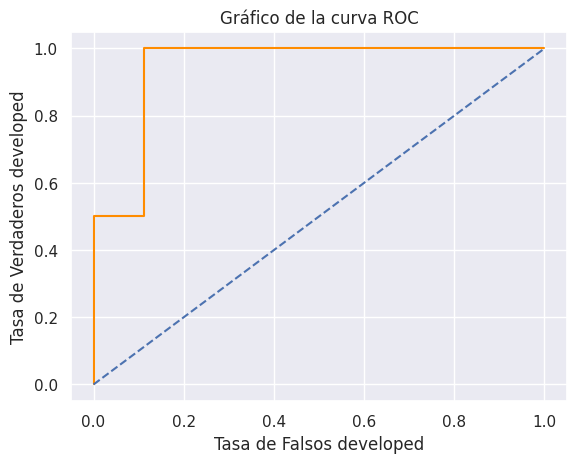

0.9444

In [73]:
# Gráfico de la curva ROC de probabilidades de developed
prob_desertor_lr_sb = proba_predicciones_lr_sb[:, 1]
fallout, sensitivity, thresholds = roc_curve(y_test, prob_desertor_lr_sb)
plt.plot(fallout, sensitivity, color = 'darkorange')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Gráfico de la curva ROC')
plt.xlabel('Tasa de Falsos developed')
plt.ylabel('Tasa de Verdaderos developed')
plt.show()

# Calcula el AUC y lo guarda en una variable
auc_lr_sb = round(roc_auc_score(y_test, prob_desertor_lr_sb),4)
auc_lr_sb

## Matriz de confusión

In [74]:
# crea la variable "etiqueta predicha" según un umbral (threshold) de 0.5
proba_predicciones_lr_sb_df['etiqueta_predicha'] = proba_predicciones_lr_sb_df['prob_developed'].apply(lambda x: 1 if x > 0.5 else 0)

# imprime la matriz de confusión
print(confusion_matrix(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha']))

#procedimiento para el calculo de la precisión general del modelo
developing_pred_correctamente  = confusion_matrix(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha'])[0][0]
developed_pred_correctamente = confusion_matrix(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha'])[1][1]
total_paises = sum(sum(confusion_matrix(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha'])))
precision_general_modelo_lr_sb = round((developed_pred_correctamente+developing_pred_correctamente)/total_paises,4)
precision_general_modelo_lr_sb

[[34  2]
 [ 2  2]]


0.9

## Procedimiento para seleccionar el Umbral (threshhold)

In [75]:
# se crea la lista de umbrales a ser probados
thresh_lr_sb = list(np.arange(0.01, 0.9, 0.01).round(2))

# crea lista de % de "Developed" predichos correctamente por el modelo según los diferentes umbrales
# (del total de Developed en la muestra de prueba cuantos el modelo predijo correctamente )
def_recalls_lr_sb = []
for i in thresh_lr_sb:
    # crea la variable "etiqueta predicha" según un umbral (threshold) "i"
    proba_predicciones_lr_sb_df['etiqueta_predicha'] = proba_predicciones_lr_sb_df['prob_developed'].apply(lambda x: 1 if x > i else 0)

    # Calcula y guarda el valor de la % sensibilidad del reporte "classification report"
    default_recall_lr_sb = round(precision_recall_fscore_support(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha'])[1][1],4)
    def_recalls_lr_sb.append(default_recall_lr_sb)

# crea lista de % de "Developing" predichos correctamente por el modelo según los diferentes umbrales
# (del total de Developing en la muestra de prueba, cuantos el modelo predijo correctamente )
nondef_recalls_lr_sb = []
for i in thresh_lr_sb:
    # crea la variable "etiqueta predicha" según un umbral (threshold) "i"
    proba_predicciones_lr_sb_df['etiqueta_predicha'] = proba_predicciones_lr_sb_df['prob_developed'].apply(lambda x: 1 if x > i else 0)

    # Calcula y guarda el valor de la % sensibilidad del reporte "classification report"
    nondef_recall_lr_sb = round(precision_recall_fscore_support(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha'])[1][0],4)
    nondef_recalls_lr_sb.append(nondef_recall_lr_sb)


accs_lr_sb = []
for i in thresh_lr_sb:
    # crea la variable "etiqueta predicha" según un umbral (threshold) "i"
    proba_predicciones_lr_sb_df['etiqueta_predicha'] = proba_predicciones_lr_sb_df['prob_developed'].apply(lambda x: 1 if x > i else 0)

    #procedimiento para el calculo de la precisión general del modelo
    developing_pred_correctamente_lr_sb  = confusion_matrix(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha'])[0][0]
    developed_pred_correctamente_lr_sb = confusion_matrix(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha'])[1][1]
    total_paises_lr_sb = sum(sum(confusion_matrix(y_test,proba_predicciones_lr_sb_df['etiqueta_predicha'])))
    precision_general_modelo_lr_sb = round((developed_pred_correctamente_lr_sb+developing_pred_correctamente_lr_sb)/total_paises_lr_sb,4)
    # Calcula y guarda el valor de la % sensibilidad del reporte "classification report"
    acc_lr_sb = precision_general_modelo_lr_sb
    accs_lr_sb.append(acc_lr_sb)

## Gráfico de umbrales y precisiones

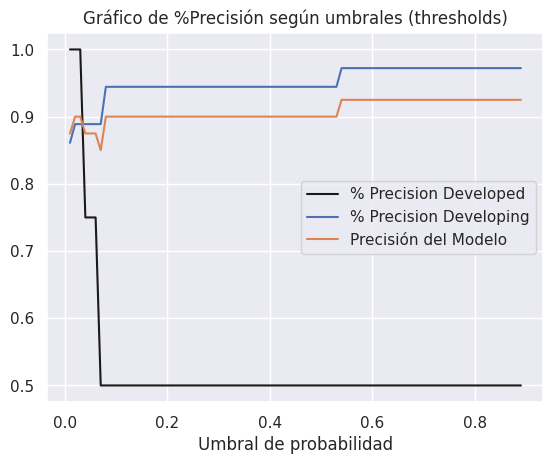

In [76]:
plt.plot(thresh_lr_sb,def_recalls_lr_sb,'k')
plt.plot(thresh_lr_sb,nondef_recalls_lr_sb)
plt.plot(thresh_lr_sb,accs_lr_sb)
plt.title("Gráfico de %Precisión según umbrales (thresholds)")
plt.xlabel("Umbral de probabilidad")
plt.legend(["% Precision Developed","% Precision Developing","Precisión del Modelo"], loc=5)
plt.show()

## Exportación de los resultados a Excel

In [77]:
#crea dataframe de codclis y etiquetas reales en la base de prueba
y_test
index = y_test.index
country_test = data['Country'].filter(items = index, axis=0)
country_ytest = pd.concat([country_test, y_test], axis = 1)
country_ytest

# # crea Data Frame con las probabilidades de ser desertor con los estudiantes de la BD de prueba
predicciones_lr_sb_df = pd.DataFrame(proba_predicciones_lr_sb[:,1], columns = ['prob_developed'])
predicciones_lr_sb_df

# # crea las columna de etiquetas predichas basadas en las probabilidades predichas y el umbral 0.024
# # la función lambda sirve para recodificar una variable
predicciones_lr_sb_df['etiqueta_predicha'] = predicciones_lr_sb_df['prob_developed'].apply(lambda x: 1 if x > 0.5 else 0)

country_ytest_predicciones_lr_sb = pd.concat([country_ytest.reset_index(drop = True), predicciones_lr_sb_df], axis = 1)
# #codcli_ytest_predicciones_lr_sb.to_excel("predicts_lr_sb_notas_acum.xlsx", index = False)
country_ytest_predicciones_lr_sb

,Country,Status,prob_developed,etiqueta_predicha
0,Papua New Guinea,0,0.0,0
1,Vanuatu,0,0.0,0
2,Chad,0,0.0,0
3,Azerbaijan,0,0.0,0
4,Comoros,0,0.0,0
5,Pakistan,0,0.0,0
6,South Africa,0,0.0,0
7,Russian Federation,0,0.1,0
8,Gabon,0,0.0,0
9,Sao Tome and Principe,0,0.0,0
